## Plot phyloregression

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path

VALID_COORD_METHODS = {"standard", "sqrt_plus_10", "log_plus_10"}

def load_all_results(dir, tree_names=["heggarty2024", "long_v3_CCD0.0.25"]):
    """Load all phylolm/lm and OAK results."""
    
    phylolm_bayesian_results = []
    oak_results = []
    
    # Load phylolm_bayesian results
    csv_files = []
    for tree_name in tree_names:
        csv_files += glob.glob(f"{dir}/phylolm_*{tree_name}*.csv")

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        filename = Path(csv_file).stem
        if "tree" not in df.columns:
            for tree_name in tree_names:
                if tree_name in filename:
                    df["tree"] = tree_name
                    break
        if "coordinate_method" not in df.columns:
            guess = filename.split("_")[-1]
            df["coordinate_method"] = guess if guess in VALID_COORD_METHODS else "standard"
        phylolm_bayesian_results.append(df)

    for phylolm_bayesian_df in phylolm_bayesian_results:
        if 'interaction' in phylolm_bayesian_df.columns:
            phylolm_bayesian_df.rename(columns={'interaction': 'interactionbool'}, inplace=True)

    # Load OAK Sobol indices
    for tree_name in tree_names:
        sobol_path = f"{dir}/oak_sobol_{tree_name}.csv"
        if Path(sobol_path).exists():
            df = pd.read_csv(sobol_path)
            df['tree'] = tree_name
            oak_results.append(df)

    # Combine dataframes
    phylolm_bayesian_df = pd.concat(phylolm_bayesian_results, ignore_index=True) if phylolm_bayesian_results else pd.DataFrame()
    oak_df = pd.concat(oak_results, ignore_index=True) if oak_results else pd.DataFrame()

    return phylolm_bayesian_df, oak_df


# Load the data
dir = "final_phyloregression_results"
phylolm_bayesian_df, oak_df = load_all_results(dir=dir)
# rename tree names for plotting
tree_name_map = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech (25%)"
}
phylolm_bayesian_df['tree'] = phylolm_bayesian_df['tree'].map(tree_name_map)
oak_df['tree'] = oak_df['tree'].map(tree_name_map)

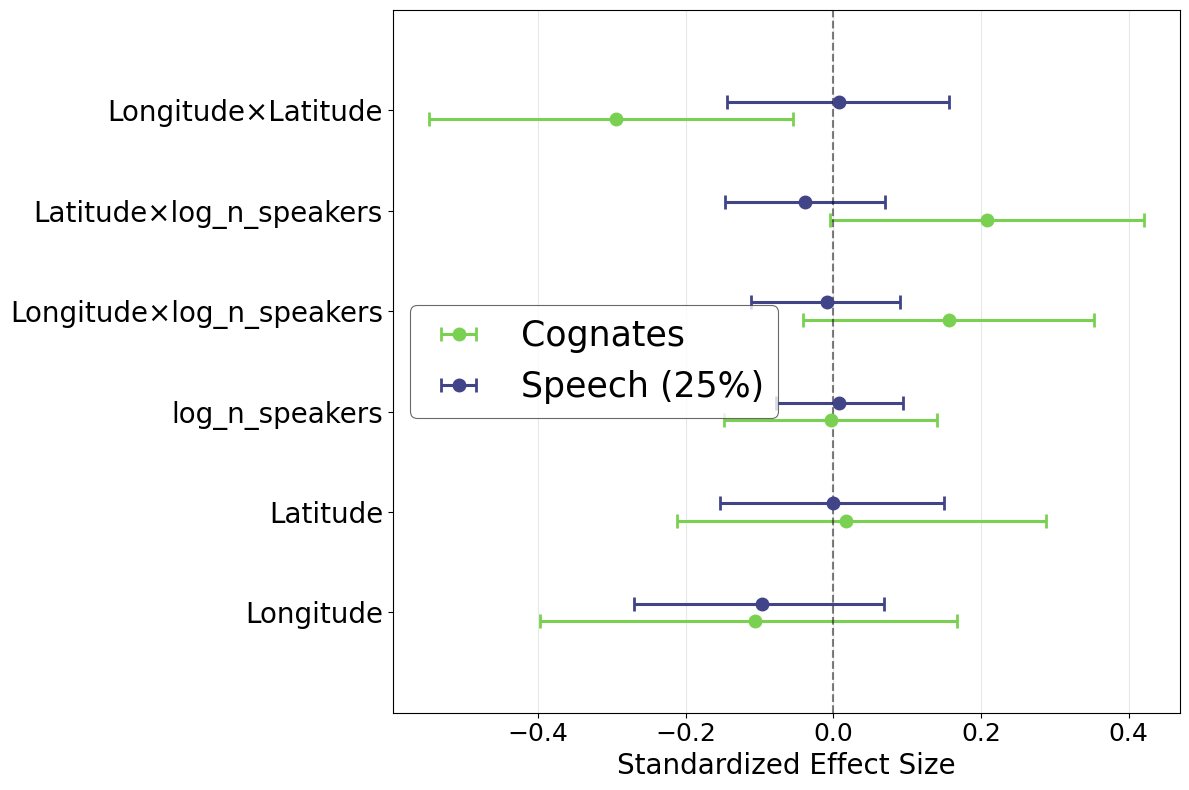

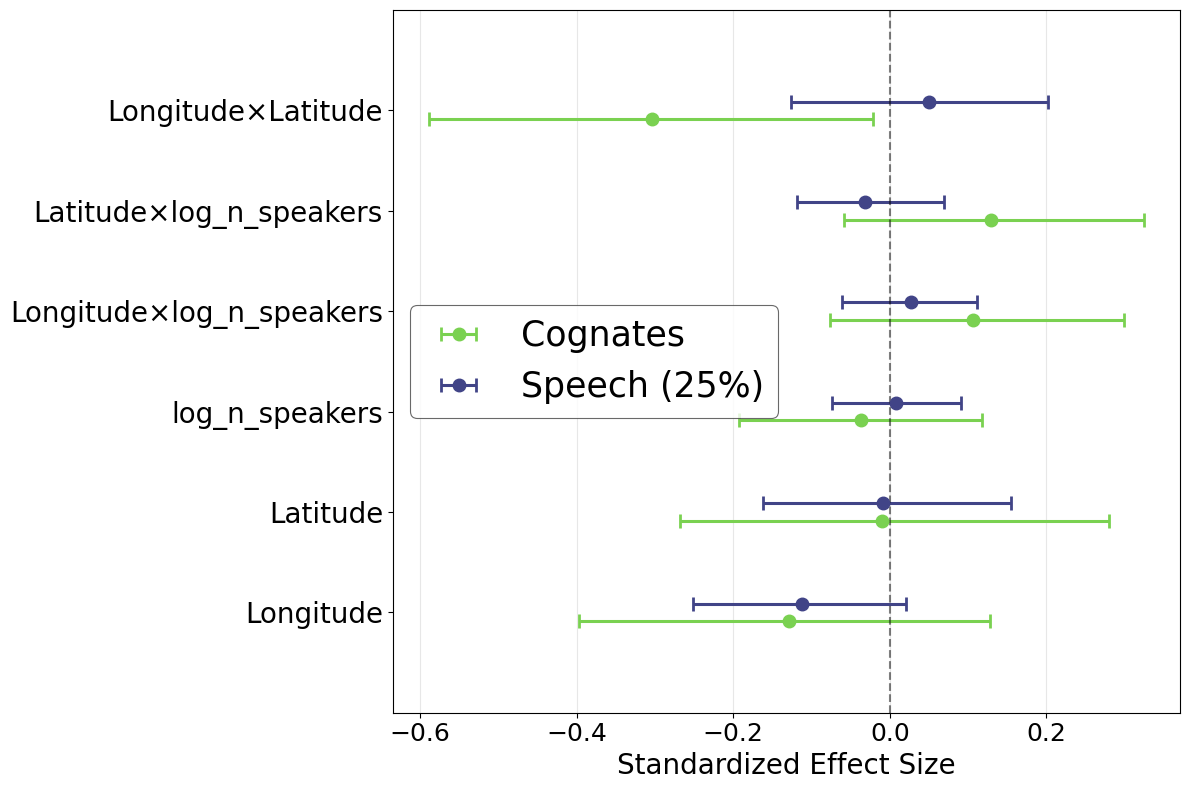

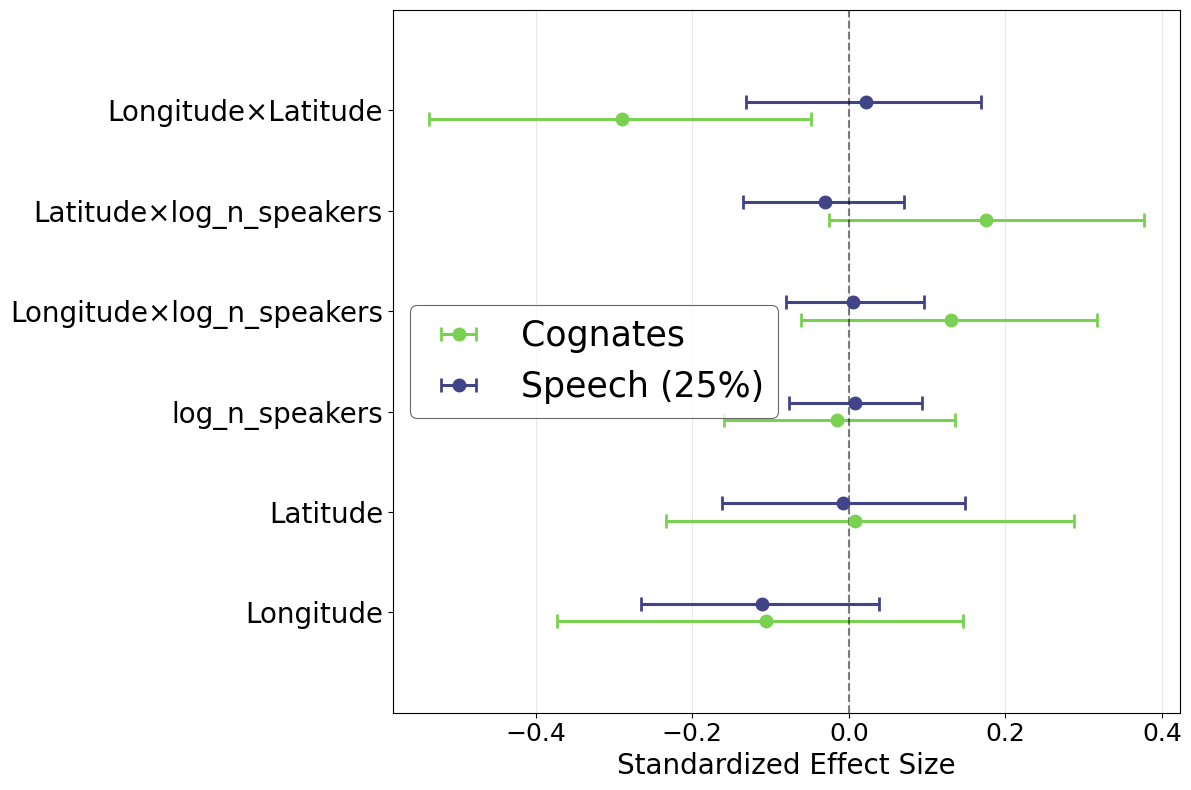

In [8]:
"""Visualization of Bayesian phylogenetic regression coefficients."""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional


# --- Configuration ---
COEFF_ORDER = [
    "Longitude",
    "Latitude",
    "log_n_speakers",
    "Longitude×log_n_speakers",
    "Latitude×log_n_speakers",
    "Longitude×Latitude",
]

COEF_COLUMN_MAP = {
    "Longitude": ("coef_longitude", "ci_lower_longitude", "ci_upper_longitude"),
    "Latitude": ("coef_latitude", "ci_lower_latitude", "ci_upper_latitude"),
    "log_n_speakers": ("coef_log_n_speakers", "ci_lower_log_n_speakers", "ci_upper_log_n_speakers"),
    "Longitude×log_n_speakers": ("coef_longitude_log_n_speakers", "ci_lower_longitude_log_n_speakers", "ci_upper_longitude_log_n_speakers"),
    "Latitude×log_n_speakers": ("coef_latitude_log_n_speakers", "ci_lower_latitude_log_n_speakers", "ci_upper_latitude_log_n_speakers"),
    "Longitude×Latitude": ("coef_longitude_latitude", "ci_lower_longitude_latitude", "ci_upper_longitude_latitude"),
}

PLOT_STYLE = {
    "figsize": (12, 8),
    "row_spacing": 4.0,
    "capsize": 5,
    "capthick": 2,
    "markersize": 9,
    "linewidth": 2.2,
    "ylabel_fontsize": 20,
    "xlabel_fontsize": 20,
    "tick_fontsize": 18,
    "legend_fontsize": 25,
}


def _ensure_dir(path: str) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)


def _extract_coefficient_data(df: pd.DataFrame) -> pd.DataFrame:
    """Extract coefficient estimates and CIs from the raw results DataFrame."""
    rows = []
    for _, row in df.iterrows():
        tree = str(row["tree"])
        for display_name, (coef_col, ci_lower, ci_upper) in COEF_COLUMN_MAP.items():
            if not {coef_col, ci_lower, ci_upper}.issubset(df.columns):
                continue
            est, lower, upper = row.get(coef_col), row.get(ci_lower), row.get(ci_upper)
            if pd.notna(est) and pd.notna(lower) and pd.notna(upper):
                rows.append({
                    "coefficient": display_name,
                    "tree": tree,
                    "estimate": float(est),
                    "ci_lower": float(lower),
                    "ci_upper": float(upper),
                })
    return pd.DataFrame(rows)


def plot_bayesian_effects_comparison(
    phylolm_df: pd.DataFrame,
    output_path: str = "final_figuresv2/effects_comparison_bayesian_normalized.pdf",
    tree_colors = None,
) -> None:
    """
    Plot standardized effects with 95% credible intervals by coefficient and tree.
    
    Visualizes posterior coefficient estimates from Bayesian phylogenetic regression
    (e.g., brms with phylogenetic correlation structure) as a forest plot.
    
    Parameters
    ----------
    phylolm_df : pd.DataFrame
        Results DataFrame with columns: tree, coef_*, ci_lower_*, ci_upper_*
    output_path : str
        Path to save the figure (PDF)
    tree_colors : dict, optional
        Mapping from tree name to RGBA color tuple
    """
    if phylolm_df.empty:
        print("No Bayesian phylo results available.")
        return

    # Extract and deduplicate
    df = _extract_coefficient_data(phylolm_df)
    df = df.drop_duplicates(subset=["tree", "coefficient"])
    
    if df.empty:
        print("No coefficients matched the expected set.")
        return

    # Order coefficients
    df = df[df["coefficient"].isin(COEFF_ORDER)]
    df["coefficient"] = pd.Categorical(df["coefficient"], categories=COEFF_ORDER, ordered=True)
    df = df.sort_values(["coefficient", "tree"])

    # #7ad151 for cognates and #414487 for speech
    tree_colors = {
        "Cognates": "#7ad151",
        "Speech (25%)": "#414487"
    }
    trees = df["tree"].unique().tolist()

    # --- Plotting ---
    style = PLOT_STYLE
    fig, ax = plt.subplots(figsize=style["figsize"])
    
    y_base = np.arange(len(COEFF_ORDER)) * style["row_spacing"]
    offsets = np.linspace(-0.35, 0.35, len(trees)) if len(trees) > 1 else [0.0]

    for offset, tree in zip(offsets, trees):
        subset = df[df["tree"] == tree].set_index("coefficient").reindex(COEFF_ORDER)
        est = subset["estimate"].to_numpy(dtype=float)
        ci_lo = subset["ci_lower"].to_numpy(dtype=float)
        ci_hi = subset["ci_upper"].to_numpy(dtype=float)
        
        valid = ~np.isnan(est)
        if not valid.any():
            continue

        y_pos = y_base[valid] + offset
        ax.errorbar(
            est[valid], y_pos,
            xerr=[est[valid] - ci_lo[valid], ci_hi[valid] - est[valid]],
            fmt="o",
            color=tree_colors.get(tree, "gray"),
            capsize=style["capsize"],
            capthick=style["capthick"],
            markersize=style["markersize"],
            linewidth=style["linewidth"],
            label=tree,
        )

    # Styling
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_yticks(y_base)
    ax.set_yticklabels(COEFF_ORDER, fontsize=style["ylabel_fontsize"])
    ax.set_ylim(-style["row_spacing"], y_base[-1] + style["row_spacing"])
    ax.set_xlabel("Standardized Effect Size", fontsize=style["xlabel_fontsize"])
    ax.tick_params(axis="x", labelsize=style["tick_fontsize"])
    ax.grid(True, axis="x", alpha=0.3)
    
    legend = ax.legend(loc="best", fontsize=style["legend_fontsize"])
    legend.get_frame().set_linewidth(0.8)
    legend.get_frame().set_edgecolor("#444444")

    plt.tight_layout()
    _ensure_dir(output_path)
    # plt.savefig(output_path, dpi=300, bbox_inches="tight")
    # save SVG
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# --- Usage ---
if __name__ == "__main__":
    # Example: assumes phylolm_bayesian_df is already loaded
    plot_bayesian_effects_comparison(phylolm_bayesian_df[phylolm_bayesian_df['coordinate_method'] == "standard"], output_path="final_figuresv2/effects_comparison_standard.svg")
    plot_bayesian_effects_comparison(phylolm_bayesian_df[phylolm_bayesian_df['coordinate_method'] == "log_plus_10"], output_path="final_figuresv2/effects_comparison_log_plus_10.svg")
    plot_bayesian_effects_comparison(phylolm_bayesian_df[phylolm_bayesian_df['coordinate_method'] == "sqrt_plus_10"], output_path="final_figuresv2/effects_comparison_sqrt_plus_10.svg")

In [9]:
phylolm_bayesian_df

,model,tree,coordinate_method,coef_Intercept,se_Intercept,ci_lower_Intercept,ci_upper_Intercept,coef_longitude,se_longitude,ci_lower_longitude,...,prop_longitude_norm_log_n_speakers_norm_q97_5,phylo_var_mean,phylo_prop_mean,phylo_prop_q2_5,phylo_prop_q97_5,residual_var_mean,residual_prop_mean,residual_prop_q2_5,residual_prop_q97_5,V_trace_norm
0,brms_phylo,Cognates,sqrt_plus_10,-5.993974,0.130767,-6.263667,-5.741642,-0.105722,0.130343,-0.373064,...,0.130225,0.047055,0.155407,0.000275,0.554012,0.121198,0.511358,0.196714,0.792481,7.157015
1,brms_phylo,Cognates,standard,-6.018256,0.133148,-6.294809,-5.759831,-0.106506,0.143940,-0.397533,...,0.139110,0.055799,0.176268,0.000257,0.577283,0.114876,0.481954,0.154329,0.780551,7.157015
2,brms_phylo,Cognates,log_plus_10,-5.961751,0.126610,-6.218070,-5.711659,-0.128506,0.132122,-0.397503,...,0.112822,0.042826,0.143417,0.000171,0.559804,0.126545,0.540525,0.208329,0.803952,7.157015
3,brms_phylo,Speech (25%),sqrt_plus_10,1.894001,0.103417,1.691269,2.098278,-0.110980,0.076206,-0.265614,...,0.066337,0.064154,0.705057,0.410596,0.917230,0.004688,0.050508,0.000536,0.256793,4.575368
4,brms_phylo,Speech (25%),standard,1.880076,0.103550,1.671515,2.085307,-0.096739,0.085919,-0.269863,...,0.072278,0.065890,0.718727,0.425655,0.923965,0.005256,0.057146,0.000813,0.284140,4.575368
5,brms_phylo,Speech (25%),log_plus_10,1.893010,0.104694,1.706486,2.104239,-0.111561,0.065720,-0.251278,...,0.067445,0.062045,0.710034,0.394481,0.912878,0.005163,0.056886,0.001306,0.278812,4.575368


## OAK Sobol

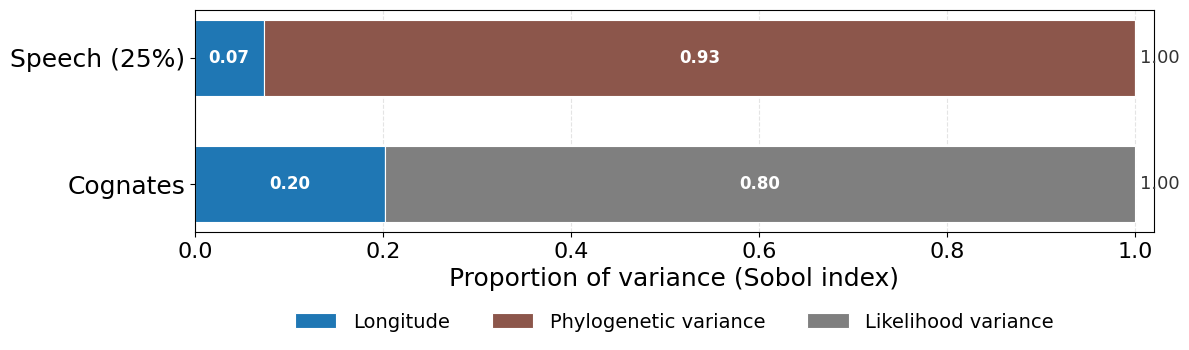

Saved stacked Sobol plot to final_figuresv2/oak_stacked_by_tree.svg


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SOBOL_COMPONENT_ORDER = [
    "Longitude",
    "Latitude",
    "log_n_speakers",
    "Longitude×log_n_speakers",
    "Latitude×log_n_speakers",
    "Longitude×Latitude",
    "Phylogenetic variance",
    "Likelihood variance",
]

SOBOL_COLORS = {
    "Longitude": "#1f77b4",
    "Latitude": "#ff7f0e",
    "log_n_speakers": "#2ca02c",
    "Longitude×log_n_speakers": "#9467bd",
    "Latitude×log_n_speakers": "#e377c2",
    "Longitude×Latitude": "#d62728",
    "Phylogenetic variance": "#8c564b",
    "Likelihood variance": "#7f7f7f",
}

_SOBOL_COMPONENT_ALIASES = {
    "lon": "Longitude",
    "longitude": "Longitude",
    "x": "Longitude",
    "lat": "Latitude",
    "latitude": "Latitude",
    "y": "Latitude",
    "log_speakers": "log_n_speakers",
    "logspeakers": "log_n_speakers",
    "log_n_speakers": "log_n_speakers",
    "logn_speakers": "log_n_speakers",
    "lon&log_speakers": "Longitude×log_n_speakers",
    "lon&logspeakers": "Longitude×log_n_speakers",
    "lon&log_n_speakers": "Longitude×log_n_speakers",
    "x&log_speakers": "Longitude×log_n_speakers",
    "x&logspeakers": "Longitude×log_n_speakers",
    "lat&log_speakers": "Latitude×log_n_speakers",
    "lat&logspeakers": "Latitude×log_n_speakers",
    "y&log_speakers": "Latitude×log_n_speakers",
    "y&logspeakers": "Latitude×log_n_speakers",
    "lon&lat": "Longitude×Latitude",
    "lonlat": "Longitude×Latitude",
    "x&y": "Longitude×Latitude",
    "normalized_phylo_variance": "Phylogenetic variance",
    "normalized_phylovariance": "Phylogenetic variance",
    "normalized_phylocovariance": "Phylogenetic variance",
    "normalized_likelihood_variance": "Likelihood variance",
}


def _map_sobol_component(raw_name):
    """Collapse raw interaction labels to display-friendly component names."""
    if pd.isna(raw_name):
        return None
    key = str(raw_name).strip().lower().replace(" ", "")
    key = key.replace("logn", "log_n")
    return _SOBOL_COMPONENT_ALIASES.get(key)


def plot_oak_sobol_stacked_by_tree(
    oak_df: pd.DataFrame,
    tree_order=None,
    output_dir: str = "final_figuresv2",
    file_stub: str = "oak_stacked_by_tree",
) -> None:
    """Plot Sobol variance fractions as stacked horizontal bars per tree."""
    if oak_df is None or oak_df.empty:
        print("oak_df is empty; nothing to plot.")
        return

    df = oak_df.copy()
    df["component"] = df["interaction"].map(_map_sobol_component)
    df = df.dropna(subset=["component", "sobol_index"])

    if df.empty:
        print("No recognised Sobol components to plot.")
        return

    summary = df.groupby(["tree", "component"])["sobol_index"].mean().unstack(fill_value=0.0)

    # Ensure all components exist
    for comp in SOBOL_COMPONENT_ORDER:
        if comp not in summary.columns:
            summary[comp] = 0.0
    summary = summary[SOBOL_COMPONENT_ORDER]

    if tree_order is None:
        tree_order = list(dict.fromkeys(df["tree"]))
    summary = summary.reindex(tree_order).fillna(0.0)

    # Plot
    fig_height = max(3.8, 1.35 * len(summary.index))
    fig, ax = plt.subplots(figsize=(12, fig_height))

    y_positions = np.arange(len(summary.index))
    left = np.zeros(len(summary.index))

    for comp in SOBOL_COMPONENT_ORDER:
        values = summary[comp].to_numpy(dtype=float)
        if np.allclose(values, 0.0):
            continue

        bars = ax.barh(
            y_positions,
            values,
            left=left,
            height=0.6,
            color=SOBOL_COLORS.get(comp, "#999999"),
            edgecolor="white",
            linewidth=0.8,
            label=comp,
        )

        # Add value labels
        for bar in bars:
            width = bar.get_width()
            if width < 0.07:
                continue
            ax.text(
                bar.get_x() + width / 2.0,
                bar.get_y() + bar.get_height() / 2.0,
                f"{width:.2f}",
                ha="center",
                va="center",
                fontsize=12,
                color="white",
                fontweight="bold",
                clip_on=False,
            )
        left += values

    ax.set_yticks(y_positions)
    ax.set_yticklabels(summary.index, fontsize=18)
    ax.set_xlabel("Proportion of variance (Sobol index)", fontsize=18)
    ax.set_xlim(0, 1.02)
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle="--", color="#bcbcbc", alpha=0.4)
    ax.set_axisbelow(True)

    # Total labels
    totals = summary.sum(axis=1).to_numpy()
    for ypos, total in zip(y_positions, totals):
        ax.text(1.005, ypos, f"{total:.2f}", va="center", ha="left", fontsize=13, color="#333333")

    legend = ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4, frameon=False, fontsize=15
    )
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(14)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    pdf_path = os.path.join(output_dir, f"{file_stub}.svg")
    plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved stacked Sobol plot to {pdf_path}")


plot_oak_sobol_stacked_by_tree(oak_df)

In [5]:
import pandas as pd

# load one CSV
df = pd.read_csv("final_phyloregression_results/phylolm_heggarty2024_standard.csv")
row = df.iloc[0]

# pick the term-variance columns you care about
term_cols = [
    "var_longitude_norm",
    "var_latitude_norm",
    "var_log_n_speakers_norm",
    "var_longitude_norm_latitude_norm",
    "var_latitude_norm_log_n_speakers_norm",
    "var_longitude_norm_log_n_speakers_norm",
]

sum_term = row[term_cols].sum()
fixed = row["fixed_var_mean"]

print("fixed_var_mean:", fixed)
print("sum(term variances):", sum_term)
print("sum_term - fixed:", sum_term - fixed)
print("ratio sum_term/fixed:", sum_term / fixed)
print("implied covariance contribution (fixed - sum_term):", fixed - sum_term)


fixed_var_mean: 0.0897095563675724
sum(term variances): 0.2459208887090859
sum_term - fixed: 0.15621133234151352
ratio sum_term/fixed: 2.74130091226245
implied covariance contribution (fixed - sum_term): -0.15621133234151352


Variance decomposition summary (standard):

Cognates:
  Longitude: 0.053 (95% CI: 0.011–0.138)
  Latitude: 0.042 (95% CI: 0.006–0.130)
  log_n_speakers: 0.020 (95% CI: 0.002–0.082)
  Longitude×Latitude: 0.137 (95% CI: 0.015–0.298)
  Latitude×log_n_speakers: 0.044 (95% CI: 0.008–0.129)
  Longitude×log_n_speakers: 0.046 (95% CI: 0.006–0.139)
  Phylogenetic: 0.176 (95% CI: 0.000–0.577)
  Residual: 0.482 (95% CI: 0.154–0.781)

Speech:
  Longitude: 0.079 (95% CI: 0.005–0.218)
  Latitude: 0.044 (95% CI: 0.004–0.147)
  log_n_speakers: 0.017 (95% CI: 0.001–0.075)
  Longitude×Latitude: 0.041 (95% CI: 0.004–0.131)
  Latitude×log_n_speakers: 0.021 (95% CI: 0.002–0.081)
  Longitude×log_n_speakers: 0.021 (95% CI: 0.003–0.072)
  Phylogenetic: 0.719 (95% CI: 0.426–0.924)
  Residual: 0.057 (95% CI: 0.001–0.284)


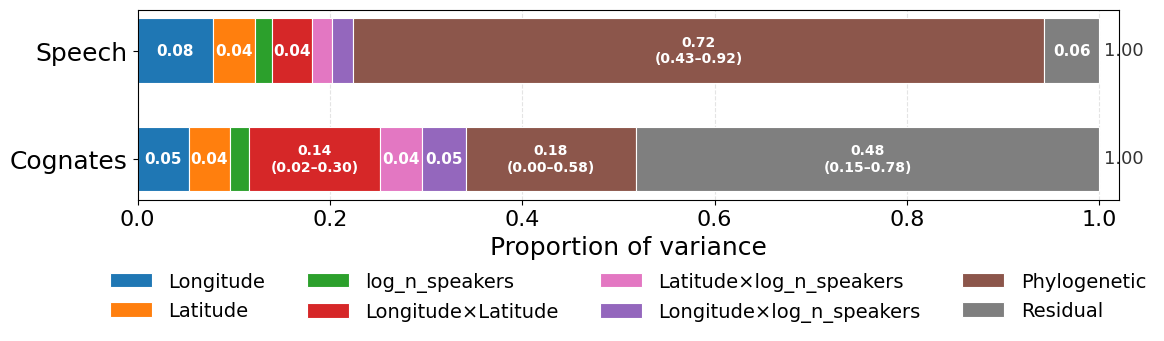

Variance decomposition summary (sqrt_plus_10):

Cognates:
  Longitude: 0.044 (95% CI: 0.009–0.117)
  Latitude: 0.047 (95% CI: 0.007–0.139)
  log_n_speakers: 0.022 (95% CI: 0.003–0.085)
  Longitude×Latitude: 0.141 (95% CI: 0.014–0.312)
  Latitude×log_n_speakers: 0.039 (95% CI: 0.006–0.120)
  Longitude×log_n_speakers: 0.041 (95% CI: 0.005–0.130)
  Phylogenetic: 0.155 (95% CI: 0.000–0.554)
  Residual: 0.511 (95% CI: 0.197–0.792)

Speech:
  Longitude: 0.096 (95% CI: 0.005–0.249)
  Latitude: 0.045 (95% CI: 0.005–0.140)
  log_n_speakers: 0.017 (95% CI: 0.001–0.073)
  Longitude×Latitude: 0.044 (95% CI: 0.004–0.142)
  Latitude×log_n_speakers: 0.020 (95% CI: 0.002–0.075)
  Longitude×log_n_speakers: 0.024 (95% CI: 0.003–0.066)
  Phylogenetic: 0.705 (95% CI: 0.411–0.917)
  Residual: 0.051 (95% CI: 0.001–0.257)


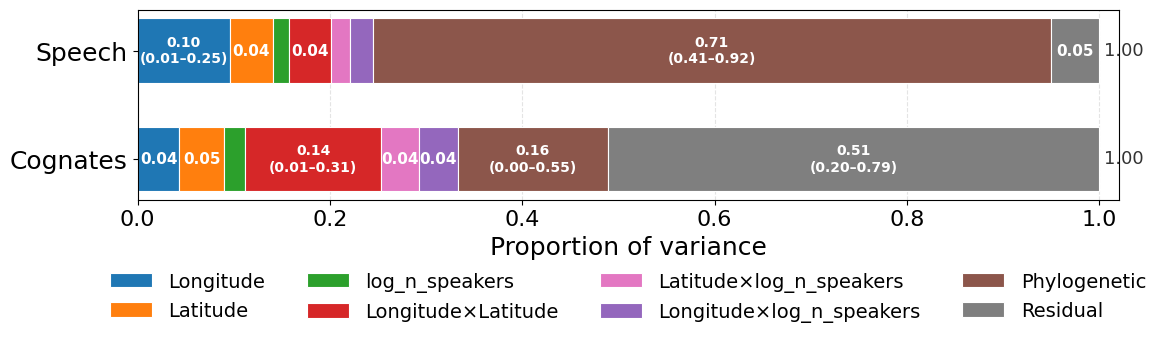

Variance decomposition summary (log_plus_10):

Cognates:
  Longitude: 0.036 (95% CI: 0.006–0.107)
  Latitude: 0.055 (95% CI: 0.008–0.154)
  log_n_speakers: 0.024 (95% CI: 0.003–0.085)
  Longitude×Latitude: 0.135 (95% CI: 0.011–0.302)
  Latitude×log_n_speakers: 0.032 (95% CI: 0.005–0.107)
  Longitude×log_n_speakers: 0.034 (95% CI: 0.004–0.113)
  Phylogenetic: 0.143 (95% CI: 0.000–0.560)
  Residual: 0.541 (95% CI: 0.208–0.804)

Speech:
  Longitude: 0.085 (95% CI: 0.006–0.226)
  Latitude: 0.040 (95% CI: 0.004–0.142)
  log_n_speakers: 0.016 (95% CI: 0.002–0.069)
  Longitude×Latitude: 0.045 (95% CI: 0.004–0.137)
  Latitude×log_n_speakers: 0.022 (95% CI: 0.002–0.072)
  Longitude×log_n_speakers: 0.025 (95% CI: 0.004–0.067)
  Phylogenetic: 0.710 (95% CI: 0.394–0.913)
  Residual: 0.057 (95% CI: 0.001–0.279)


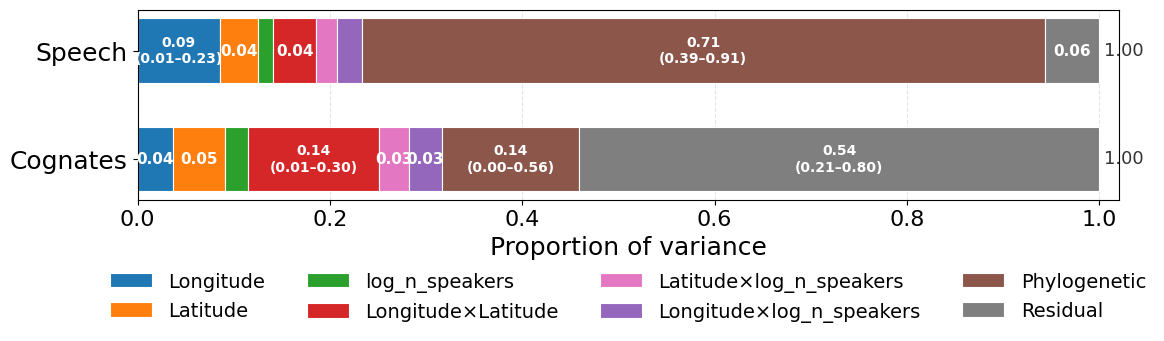

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VARIANCE_COMPONENT_ORDER = [
    "Longitude",
    "Latitude",
    "log_n_speakers",
    "Longitude×Latitude",
    "Latitude×log_n_speakers",
    "Longitude×log_n_speakers",
    "Phylogenetic",
    "Residual",
]

VARIANCE_COLORS = {
    "Longitude": "#1f77b4",
    "Latitude": "#ff7f0e",
    "log_n_speakers": "#2ca02c",
    "Longitude×Latitude": "#d62728",
    "Latitude×log_n_speakers": "#e377c2",
    "Longitude×log_n_speakers": "#9467bd",
    "Phylogenetic": "#8c564b",
    "Residual": "#7f7f7f",
}

# Map CSV column base names to display names (using prop_ prefix)
CSV_TO_DISPLAY = {
    "prop_longitude_norm": "Longitude",
    "prop_latitude_norm": "Latitude",
    "prop_log_n_speakers_norm": "log_n_speakers",
    "prop_longitude_norm_latitude_norm": "Longitude×Latitude",
    "prop_latitude_norm_log_n_speakers_norm": "Latitude×log_n_speakers",
    "prop_longitude_norm_log_n_speakers_norm": "Longitude×log_n_speakers",
}


def load_phylo_variance_results(csv_dir: str, coord_method: str = "standard") -> pd.DataFrame:
    """
    Load variance decomposition from phylogenetic regression CSVs.
    Returns proportions with 95% CI for each variance component.
    """
    pattern = os.path.join(csv_dir, f"phylolm_*_{coord_method}.csv")
    csv_files = glob.glob(pattern)

    if not csv_files:
        print(f"No CSV files found matching {pattern}")
        return pd.DataFrame()
    
    records = []
    
    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        tree_name = df["tree"].iloc[0]
        
        # Get per-term proportions with CIs
        for csv_col, display_name in CSV_TO_DISPLAY.items():
            if csv_col in df.columns:
                prop_mean = df[csv_col].iloc[0]
                q2_5_col = f"{csv_col}_q2_5"
                q97_5_col = f"{csv_col}_q97_5"
                prop_q2_5 = df[q2_5_col].iloc[0] if q2_5_col in df.columns else np.nan
                prop_q97_5 = df[q97_5_col].iloc[0] if q97_5_col in df.columns else np.nan
                
                records.append({
                    "tree": tree_name,
                    "component": display_name,
                    "variance_prop": prop_mean,
                    "prop_q2_5": prop_q2_5,
                    "prop_q97_5": prop_q97_5,
                })
        
        # Add phylogenetic proportion with CI
        records.append({
            "tree": tree_name,
            "component": "Phylogenetic",
            "variance_prop": df["phylo_prop_mean"].iloc[0],
            "prop_q2_5": df["phylo_prop_q2_5"].iloc[0],
            "prop_q97_5": df["phylo_prop_q97_5"].iloc[0],
        })
        
        # Add residual proportion with CI
        records.append({
            "tree": tree_name,
            "component": "Residual",
            "variance_prop": df["residual_prop_mean"].iloc[0],
            "prop_q2_5": df["residual_prop_q2_5"].iloc[0],
            "prop_q97_5": df["residual_prop_q97_5"].iloc[0],
        })
    
    return pd.DataFrame(records)


def plot_phylo_variance_stacked(
    csv_dir: str = "speech_phylo/final_phyloregression_results",
    coord_method: str = "standard",
    tree_order: list = None,
    tree_labels: dict = None,
    output_dir: str = "final_figuresv2",
    file_stub: str = "phyloLM_variance_stacked",
) -> None:
    """Plot variance decomposition as stacked horizontal bars per tree."""
    
    df = load_phylo_variance_results(csv_dir, coord_method)
    
    if df.empty:
        print("No data to plot.")
        return
    
    # Keep the full dataframe for CI access
    df_full = df.copy()
    
    # Pivot to get components as columns for mean proportions
    summary = df.pivot_table(
        index="tree", 
        columns="component", 
        values="variance_prop", 
        aggfunc="mean"
    ).fillna(0.0)
    
    # Also pivot for CI bounds
    summary_q2_5 = df.pivot_table(
        index="tree",
        columns="component",
        values="prop_q2_5",
        aggfunc="mean"
    ).fillna(0.0)
    
    summary_q97_5 = df.pivot_table(
        index="tree",
        columns="component",
        values="prop_q97_5",
        aggfunc="mean"
    ).fillna(0.0)

    # Ensure all components exist
    for comp in VARIANCE_COMPONENT_ORDER:
        if comp not in summary.columns:
            summary[comp] = 0.0
            summary_q2_5[comp] = 0.0
            summary_q97_5[comp] = 0.0
    summary = summary[VARIANCE_COMPONENT_ORDER]
    summary_q2_5 = summary_q2_5[VARIANCE_COMPONENT_ORDER]
    summary_q97_5 = summary_q97_5[VARIANCE_COMPONENT_ORDER]
    
    # Rename trees for display (keep original for lookup)
    tree_index_orig = list(summary.index)
    if tree_labels is not None:
        summary.index = [tree_labels.get(t, t) for t in summary.index]
        summary_q2_5.index = [tree_labels.get(t, t) for t in summary_q2_5.index]
        summary_q97_5.index = [tree_labels.get(t, t) for t in summary_q97_5.index]
    
    # Print summary with CIs
    print(f"Variance decomposition summary ({coord_method}):")
    for tree_idx, tree_display in enumerate(summary.index):
        print(f"\n{tree_display}:")
        for comp in VARIANCE_COMPONENT_ORDER:
            mean = summary.loc[tree_display, comp]
            q2_5 = summary_q2_5.loc[tree_display, comp]
            q97_5 = summary_q97_5.loc[tree_display, comp]
            if mean > 0.001:
                print(f"  {comp}: {mean:.3f} (95% CI: {q2_5:.3f}–{q97_5:.3f})")
    
    # Plot
    fig_height = max(3.8, 1.35 * len(summary.index))
    fig, ax = plt.subplots(figsize=(12, fig_height))
    
    y_positions = np.arange(len(summary.index))
    left = np.zeros(len(summary.index))
    
    for comp in VARIANCE_COMPONENT_ORDER:
        values = summary[comp].to_numpy(dtype=float)
        q2_5_vals = summary_q2_5[comp].to_numpy(dtype=float)
        q97_5_vals = summary_q97_5[comp].to_numpy(dtype=float)
        
        if np.allclose(values, 0.0):
            continue
        
        bars = ax.barh(
            y_positions,
            values,
            left=left,
            height=0.6,
            color=VARIANCE_COLORS.get(comp, "#999999"),
            edgecolor="white",
            linewidth=0.8,
            label=comp,
        )
        
        # Add value labels with 95% CI
        for i, bar in enumerate(bars):
            width = bar.get_width()
            if width < 0.03:
                continue
            
            # Format label with CI
            q2_5 = q2_5_vals[i]
            q97_5 = q97_5_vals[i]
            if width >= 0.08:  # More space: show mean and CI
                label = f"{width:.2f}\n({q2_5:.2f}–{q97_5:.2f})"
                fontsize = 10
            else:  # Less space: just show mean
                label = f"{width:.2f}"
                fontsize = 11
            
            ax.text(
                bar.get_x() + width / 2.0,
                bar.get_y() + bar.get_height() / 2.0,
                label,
                ha="center",
                va="center",
                fontsize=fontsize,
                color="white",
                fontweight="bold",
                clip_on=False,
            )
        left += values
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(summary.index, fontsize=18)
    ax.set_xlabel("Proportion of variance", fontsize=18)
    ax.set_xlim(0, 1.02)
    ax.tick_params(axis="x", labelsize=16)
    ax.grid(axis="x", linestyle="--", color="#bcbcbc", alpha=0.4)
    ax.set_axisbelow(True)
    
    # Total labels
    totals = summary.sum(axis=1).to_numpy()
    for ypos, total in zip(y_positions, totals):
        ax.text(1.005, ypos, f"{total:.2f}", va="center", ha="left", fontsize=13, color="#333333")
    
    legend = ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=4, frameon=False, fontsize=15
    )
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(14)
    
    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    file_stub = f"{file_stub}_{coord_method}"
    svg_path = os.path.join(output_dir, f"{file_stub}.svg")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
    plt.show()


# Usage:
for coord_method in ["standard", "sqrt_plus_10", "log_plus_10"]:
    plot_phylo_variance_stacked(
        csv_dir="final_phyloregression_results",
        coord_method=coord_method,
        tree_order=["long_v3_CCD0.0.25", "heggarty2024"],
        tree_labels={
            "long_v3_CCD0.0.25": "Speech",
            "heggarty2024": "Cognates",
        },
    )

## Figure 3d

(36, 1)


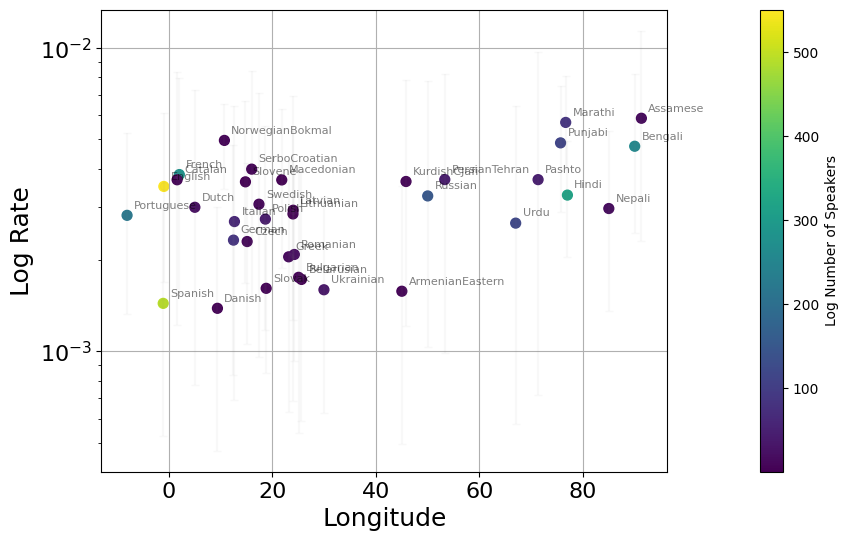

(36, 1)


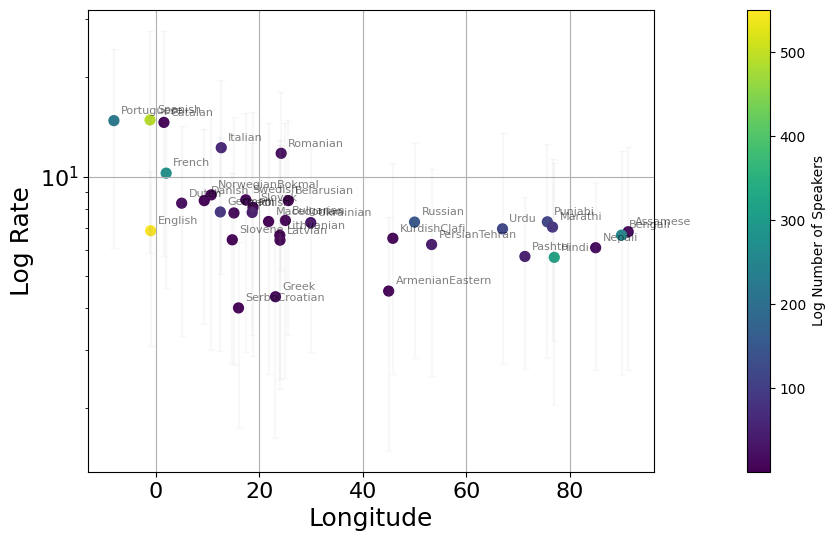

In [15]:
import numpy as np
# run_gpflow_shap.py
import os
import sys 
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import argparse
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import pandas as pd
import numpy as np

for tree_name in ["heggarty2024", "long_v3_CCD0.0.25"]:

    # ─── 2) Load metadata, letting pandas read the header row ────
    meta = pd.read_csv(f"final_phyloregression_results/metadata_{tree_name}.csv", sep=",")
    meta = meta.rename(columns={"level_0": "language_true"})
    # for columns that have the format number1,number2, make it into separate columns with columnname_lo, columnname_hi
    # the dataframe is meta
    for col in meta.columns:
        if meta[col].dtype == object and meta[col].str.contains(",").any():
            # Split into two new columns
            new_cols = meta[col].str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            # Drop the original column
            meta = meta.drop(columns=[col])
    # remove columns 1-5
    # meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.drop(columns=meta.columns[1:7], errors='ignore')
    meta = meta.rename(columns={"language_true": "language"})

    # If the column really is called "language", do:
    if "language" not in meta.columns:
        raise ValueError("Your metadata CSV does not have a column named 'language'")

    # Trim whitespace just in case
    meta["language"] = meta["language"].astype(str).str.strip()

    # Now set it as the index
    meta = meta.set_index("language")

    # ─── 4) Build X as before ───────────────────────────────
    longitudes   = meta["longitude"].to_numpy().reshape(-1, 1)
    latitudes    = meta["latitude"].to_numpy().reshape(-1, 1)
    log_speakers = np.log(meta["n_speakers"].to_numpy()).reshape(-1, 1)
    # hittite = meta["Hittite"].to_numpy().reshape(-1, 1)

    y = meta["rate_median"].to_numpy().reshape(-1, 1)
    print(y.shape)

    # plot rates vs longitude colored by n_speakers
    # plot rates vs longitude colored by n_speakers
    import matplotlib.pyplot as plt
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    sc = plt.scatter(meta["longitude"], y, c=meta["n_speakers"], cmap='viridis', s=50)
    # add 95% CI error bars. Column names are rate_95%_HPD_lo and rate_95%_HPD_hi
    # make this correct for log scale
    for lang, row in meta.iterrows():
        plt.errorbar(
            row["longitude"],
            row["rate_median"],
            yerr=[[row["rate_median"] - row["rate_95%_HPD_lo"]],
                  [row["rate_95%_HPD_hi"] - row["rate_median"]]],
            fmt='o',
            color='gray',
            alpha=0.05,
            capsize=3
        )
    # --- Label lone points with high n_speakers ---
    threshold = np.percentile(meta["n_speakers"], 95)  # top 5% as "high"
    for lang, row in meta.iterrows():
        plt.annotate(
            lang,
            (row["longitude"], row["rate_median"]),  # x,y coords
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            color="black",
            alpha=0.5
        )

    plt.yscale('log')
    plt.colorbar(sc, label='Log Number of Speakers', pad=0.12)
    # colorbar label fontsize
    plt.xlabel('Longitude', fontsize=18)
    plt.ylabel('Log Rate', fontsize=18)
    plt.tick_params(axis='x', labelsize=16)
    plt.tick_params(axis='y', labelsize=16)
    # plt.title(f'Log Rate vs longitudes colored by Number of Speakers for {tree_name}')
    plt.grid(True)

    plt.savefig(f"final_figuresv2/rate_vs_longitude_{tree_name}.svg", dpi=300)
    plt.show()

## Figure 4.5

In [16]:
import dendropy

posterior_path = "long_v3_44.trees"

trees_speech = dendropy.TreeList.get(
    path=posterior_path,
    schema="nexus",
    preserve_underscores=True
)

posterior_path = "IECoR_Main_M3_Binary_Covarion_Rates_By_Mg_Bin_combined.trees"

trees_cognates = dendropy.TreeList.get(
    path=posterior_path,
    schema="nexus",
    preserve_underscores=True
)

In [17]:
# prune trees to only those languages in trees_speech
# prune Hittite and Luvian from trees_cognates

def treelist_taxa_labels(tree_list):
    """
    Get the set of taxon labels present in (the first) tree_list.
    Assumes posterior: all trees have the same taxa.
    """
    if len(tree_list) == 0:
        return set()
    return {leaf.taxon.label for leaf in tree_list[0].leaf_node_iter()}


def prune_treelist_to_labels(tree_list, keep_labels):
    """
    Return a *new* TreeList where each tree is pruned
    to only taxa whose labels are in `keep_labels`.
    """
    pruned = dendropy.TreeList()
    for tr in tree_list:
        tr2 = tr.clone(depth=2)
        tr2.retain_taxa_with_labels(keep_labels)
        pruned.append(tr2)
    return pruned

def remove_taxa_from_treelist(tree_list, remove_labels):
    """
    Return a *new* TreeList where each tree has the specified taxa removed.
    Uses prune_taxa_with_labels (removes listed) vs retain_taxa_with_labels (keeps listed).
    """
    pruned = dendropy.TreeList()
    for tr in tree_list:
        tr2 = tr.clone(depth=2)
        tr2.prune_taxa_with_labels(remove_labels)
        tr2.suppress_unifurcations()  # Clean up degree-2 nodes
        pruned.append(tr2)
    return pruned

# 1) Get label sets
speech_labels   = treelist_taxa_labels(trees_speech)
cognate_labels  = treelist_taxa_labels(trees_cognates)

overlap         = speech_labels & cognate_labels
missing_in_cogn = speech_labels - cognate_labels
extra_in_cogn   = cognate_labels - speech_labels

print(f"Speech taxa:   {len(speech_labels)}")
print(f"Cognate taxa:  {len(cognate_labels)}")
print(f"Overlap:       {len(overlap)}")
print(f"Missing in cognates (in speech but not cognates): {sorted(missing_in_cogn)}")
print(f"Extra in cognates (not in speech):                {sorted(extra_in_cogn)}")

# 2) Prune cognate trees down to overlap
pruned_cognates = prune_treelist_to_labels(trees_cognates, overlap)
pruned_cognates.write(
    path="IECoR_Main_M3_Binary_Covarion_Rates_By_Mg_Bin_combined_prunedtospeech.trees",
    schema="nexus"
)

Speech taxa:   36
Cognate taxa:  161
Overlap:       36
Missing in cognates (in speech but not cognates): []
Extra in cognates (not in speech):                ['AlbanianArberesh', 'AlbanianGheg', 'AlbanianStandard', 'AncientGreek', 'AngloNorman', 'ArmenianWestern', 'AvestanYounger', 'Bactrian', 'Bakhtiari', 'BalochiSistani', 'Bhojpuri', 'BretonGwened', 'BretonTreger', 'ClassicalArmenian', 'DalmatianVegliote', 'Delvari', 'Elfdalian', 'Faroese', 'Flemish', 'FrancoProvencal', 'Frisian', 'Friulian', 'GaelicIrish', 'GaelicManx', 'GaelicScottish', 'Gaulish', 'Gawarbati', 'Gawri', 'GermanBernese', 'Gothic', 'GreekCappodocian', 'GreekCypriot', 'GreekItaliot', 'GreekPontic', 'Hawrami', 'Hittite', 'Icelandic', 'KalasalaNiseigram', 'Kamviri', 'Kashmiri', 'Kashubian', 'KatavariEastern', 'KatavariKtivi', 'Khotanese', 'Khowar', 'Khwarazmian', 'Kumzari', 'KurdishNBahdini', 'KurdishSElami', 'KurdishSQorveh', 'Ladin', 'Lari', 'LateCornish', 'Latgalian', 'Latin', 'Luvian', 'Luxembourgish', 'MacedonianSuh

In [ ]:
posterior_path = "IECoR_Main_M3_Binary_Covarion_Rates_By_Mg_Bin_combined_prunedtospeech.trees"

trees_cognates = dendropy.TreeList.get(
    path=posterior_path,
    schema="nexus",
    preserve_underscores=True
)

/home/people/habhuz/miniconda3/envs/speech_phylo/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1396: RuntimeWarning: All-NaN slice encountered
  overwrite_input, interpolation)
/home/people/habhuz/miniconda3/envs/speech_phylo/lib/python3.7/site-packages/ipykernel_launcher.py:211: RuntimeWarning: Mean of empty slice


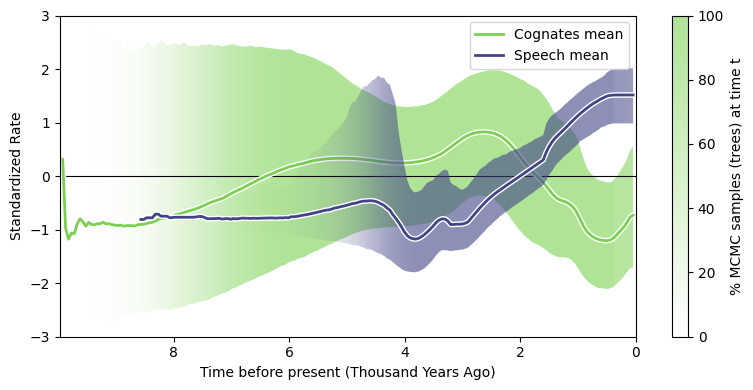

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import dendropy as dp
from matplotlib.colors import Normalize, to_rgba, LinearSegmentedColormap
import matplotlib.cm as cm
from matplotlib.collections import PolyCollection

# --- load ---
def load_trees_with_rates(path):
    return dp.TreeList.get_from_path(
        path, schema="nexus",
        preserve_underscores=True,
        extract_comment_metadata=True,  # REQUIRED to see [&rate=...]
    )

# --- extract per-branch segment: [child_age, parent_age] and rate ---
def _extract_segments(tree):
    """
    Returns arrays:
      T0: child age (younger, closer to present)
      T1: parent age (older, further in the past)
      R:  rate annotated on the edge leading to the child
    Only segments with positive duration are kept.
    """
    tree.calc_node_ages()
    T0, T1, R = [], [], []
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None:
            continue  # root has no incoming edge
        tp, tc = float(nd.parent_node.age), float(nd.age)
        if tp <= tc:
            continue  # skip zero/negative-length edges if any
        # Try node then edge annotations for "rate"
        r = nd.annotations.get_value("rate")
        if r is None and hasattr(nd, "edge"):
            r = nd.edge.annotations.get_value("rate")
        r = float(r) if r is not None else np.nan
        T0.append(tc); T1.append(tp); R.append(r)
    T0 = np.asarray(T0); T1 = np.asarray(T1); R = np.asarray(R)
    good = np.isfinite(R) & (T1 > T0)
    return T0[good], T1[good], R[good]


def _rates_over_time_slices(trees, t_grid, min_segments_per_tree=1):
    """
    For each tree and each time t in t_grid, compute the mean rate of all
    branches whose interval spans t:

        T0 < t < T1

    Returns:
      rates: array shape (n_trees, len(t_grid))
    """
    n_trees = len(trees)
    T = len(t_grid)
    rates = np.full((n_trees, T), np.nan)

    for i, tr in enumerate(trees):
        T0, T1, R = _extract_segments(tr)
        for j, t in enumerate(t_grid):
            msk = (T0 < t) & (T1 > t)
            if msk.sum() >= min_segments_per_tree:
                rates[i, j] = R[msk].mean()
    return rates


def _global_tmax(*groups):
    """Max root age across groups (after calc_node_ages)."""
    tmax = 0.0
    for group in groups:
        for tr in group:
            tr.calc_node_ages()
            tmax = max(tmax, float(tr.seed_node.age))  # root age
    return tmax


def plot_groups_same_xaxis(
    trees_A,
    trees_B,
    ntimes=200,              # number of timepoints along the x-axis
    min_segments_per_tree=1, # min branches covering t to use that tree at t
    draw_mean=True,
    tree_name=None
):
    """
    Compute instantaneous mean rate(t) for each tree at ntimes timepoints,
    then normalize by the global mean over *all* trees at each timepoint.

    Plots:
      y = rate(t) / global_mean(t)
      x = time before present
    """
    # Time grid from present to global max root age
    tmin = 0.0
    tmax = _global_tmax(trees_A, trees_B)
    t_grid = np.linspace(tmin, tmax, ntimes)

    # Per-tree instantaneous mean rates at each timepoint
    rates_A = _rates_over_time_slices(trees_A, t_grid,
                                      min_segments_per_tree=min_segments_per_tree)
    rates_B = _rates_over_time_slices(trees_B, t_grid,
                                      min_segments_per_tree=min_segments_per_tree)

    # normalize for each sample
    norm_A = (rates_A  - np.nanmean(rates_A, axis=1, keepdims=True)) / np.nanstd(rates_A, axis=1, keepdims=True, ddof=1)
    norm_B = (rates_B  - np.nanmean(rates_B, axis=1, keepdims=True)) / np.nanstd(rates_B, axis=1, keepdims=True, ddof=1)
    
    # Plot on ONE shared axis
    fig, ax = plt.subplots(figsize=(8, 4))

    color_A = "#7ad151"   # Cognates
    color_B = "#414487"   # Speech

    # ---- counts per time step for both groups (for alpha scaling) ----

    n_trees_A = norm_A.shape[0]
    n_trees_B = norm_B.shape[0]

    counts_A = np.sum(np.isfinite(norm_A), axis=0) / n_trees_A * 100  # percentage
    counts_B = np.sum(np.isfinite(norm_B), axis=0) / n_trees_B * 100
    norm_counts = Normalize(vmin=0, vmax=100)
    # y-limits we want for the plot
    ylow, yhigh = -3, 3
    ax.set_ylim(ylow, yhigh)

    # --- helpers ------------------------------------------------------
    def smooth_nan_1d(x, window=15):
        """Nan-safe moving average."""
        x = np.asarray(x, float)
        if window <= 1:
            return x
        w = int(window)
        if w % 2 == 0:
            w += 1
        mask = np.isfinite(x)
        if mask.sum() == 0:
            return x
        x_filled = np.where(mask, x, 0.0)
        kernel = np.ones(w, dtype=float)
        num = np.convolve(x_filled, kernel, mode="same")
        den = np.convolve(mask.astype(float), kernel, mode="same")
        out = num / np.where(den == 0, np.nan, den)
        return out

    def interp_nan_1d(y):
        """Linearly interpolate across NaNs so the band is continuous."""
        y = np.asarray(y, float)
        x = np.arange(len(y))
        m = np.isfinite(y)
        if m.sum() == 0:
            return y
        y2 = y.copy()
        y2[~m] = np.interp(x[~m], x[m], y[m])
        return y2

    def alpha_cmap(base_color, max_alpha=0.6):
        """Colormap where RGB is fixed = base_color, alpha goes 0→1."""
        return LinearSegmentedColormap.from_list(
            f"alpha_{base_color}",
            [to_rgba(base_color, 0.0), to_rgba(base_color, max_alpha)],
        )

    def add_alpha_band(t_grid, mat, counts, base_color, label_prefix, zorder=1):
        """
        95% CI band whose transparency encodes sample density over time.
        Hue is fixed = base_color.
        """
        # 95% CI
        q_lo = np.nanpercentile(mat, 2.5, axis=0)
        q_hi = np.nanpercentile(mat, 97.5, axis=0)

        # where CI is defined
        valid = np.isfinite(q_lo) & np.isfinite(q_hi)
        t = t_grid[valid]
        lo = q_lo[valid]
        hi = q_hi[valid]

        # base band just to get shape
        band = ax.fill_between(
            t,
            lo,
            hi,
            color="none",
            zorder=zorder,
        )

        # smooth+interpolate counts so alpha varies smoothly with t
        cnt = counts.astype(float)
        cnt = smooth_nan_1d(cnt, window=15)
        cnt = interp_nan_1d(cnt)
        cnt = np.maximum(cnt, 0.0)

        # tiny image: rows identical, columns = time; values = counts
        n_rows = 200
        cnt_img = np.tile(cnt, (n_rows, 1))

        im = ax.imshow(
            cnt_img,
            extent=(t_grid.min(), t_grid.max(), ylow, yhigh),
            origin="lower",
            aspect="auto",
            cmap=alpha_cmap(base_color),
            norm=norm_counts,
            zorder=zorder,
        )
        # clip image to CI band
        im.set_clip_path(band.get_paths()[0], transform=ax.transData)

        # mean line on top, with halo
        if draw_mean:
            mean = np.nanmean(mat, axis=0)
            mean_valid = np.isfinite(mean)

            # halo (white, thicker, underneath)
            ax.plot(
                t_grid[mean_valid],
                mean[mean_valid],
                lw=4,
                color="white",
                zorder=zorder + 1.4,
            )
            # coloured line on top
            ax.plot(
                t_grid[mean_valid],
                mean[mean_valid],
                lw=2,
                color=base_color,
                label=f"{label_prefix} mean",
                zorder=zorder + 1.5,
            )

        return im

    # ---------- group A: Cognates ----------
    imA = add_alpha_band(
        t_grid, norm_A, counts_A,
        base_color=color_A,
        label_prefix="Cognates",
        zorder=1,
    )

    # ---------- group B: Speech ----------
    imB = add_alpha_band(
        t_grid, norm_B, counts_B,
        base_color=color_B,
        label_prefix="Speech",
        zorder=3,  # draw above A if overlapping
    )

    # Axes formatting
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlim(tmax, tmin)           # time before present, reversed
    ax.set_ylim(ylow, yhigh)
    ax.set_xlabel("Time before present (Thousand Years Ago)")
    ax.set_ylabel("Standardized Rate")
    ax.legend()

    # Colorbar for sample density (optional)
    sm = cm.ScalarMappable(norm=norm_counts, cmap=alpha_cmap(color_A))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("% MCMC samples (trees) at time t")

    fig.tight_layout()

    # save as svg too
    plt.savefig(
        f"final_figuresv2/rate_over_time_normalized.svg",
        dpi=300
    )
    plt.show()

    # tC, C, tS, S style return for backward-compat:
    tC, C = t_grid, norm_A
    tS, S = t_grid, norm_B
    return tC, C, tS, S

tC, C, tS, S = plot_groups_same_xaxis(
    trees_cognates[1000:], trees_speech[1000:],
    ntimes=200,
    min_segments_per_tree=1,
)

## Workflow

In [11]:
# Generate waveform-style figures with play buttons and varied wave patterns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

out_dir = Path("./final_figuresv2/")
out_dir.mkdir(parents=True, exist_ok=True)

def smooth_random(n, seed=0, k=7):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0.2, 1.0, size=n + k - 1)
    kernel = np.ones(k) / k
    y = np.convolve(x, kernel, mode="valid")
    y = (y - y.min()) / (y.max() - y.min() + 1e-8)
    return 0.15 + 0.85 * y

def make_patterns(n):
    x = np.linspace(0, 1, n)
    # 1) Gaussian-sine
    g = np.exp(-((x - 0.5) ** 2) / (2 * 0.12**2))
    p1 = 0.15 + 0.85 * (g * (0.5 + 0.5 * np.sin(10 * np.pi * x)))

    # 2) Triangular envelope + sine
    tri = 1 - np.abs(2 * x - 1)
    p2 = 0.15 + 0.85 * (tri * (0.6 + 0.4 * np.sin(6 * np.pi * x)))

    # 3) Smooth random
    p3 = smooth_random(n, seed=1)

    # 4) Clustered: high left, gap mid, lower right
    left = 0.4 + 0.6 * (0.5 + 0.5 * np.sin(7 * np.pi * x))
    right = 0.2 + 0.5 * (0.5 + 0.5 * np.cos(9 * np.pi * x))
    mid_gap = np.clip(1 - 12 * (x - 0.5) ** 2, 0, 1)
    p4 = np.where(mid_gap > 0.8, 0.2, np.where(x < 0.4, left, right))
    p4 = 0.1 + 0.9 * (p4 - p4.min()) / (p4.max() - p4.min() + 1e-8)

    # 5) Exponential decay
    p5 = 0.15 + 0.85 * (np.exp(-3 * x) * (0.4 + 0.6 * (0.5 + 0.5 * np.sin(8 * np.pi * x))))

    # 6) Alternating high/low
    p6 = 0.2 + 0.8 * ((np.arange(n) % 2) * 0.9 + (1 - (np.arange(n) % 2)) * 0.2)

    # 7) Bursts
    bursts = ((np.sin(2 * np.pi * (3 * x)) > 0.6).astype(float) +
              (np.sin(2 * np.pi * (7 * x + 0.2)) > 0.8).astype(float))
    bursts = bursts / (bursts.max() + 1e-8)
    p7 = 0.1 + 0.9 * (0.3 + 0.7 * bursts)

    # 8) Mirror random
    half = smooth_random(n // 2, seed=7)
    p8 = np.concatenate([half, half[::-1]])
    if len(p8) < n:
        p8 = np.concatenate([p8, [p8[-1]]])

    return [p1, p2, p3, p4, p5, p6, p7, p8]

def draw_row(ax, heights, filled=True, outline=False):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # --- circular play button in an inset axis ---
    iax = inset_axes(ax, width="9%", height="55%", loc="center left", borderpad=1.3)
    iax.set_xlim(0, 1)
    iax.set_ylim(0, 1)
    iax.set_aspect("equal")      # keeps the button perfectly circular
    iax.axis("off")

    circle = Circle((0.5, 0.5), 0.48, facecolor="black", edgecolor="black", lw=1)
    iax.add_patch(circle)
    tri = Polygon([[0.42, 0.32],
                   [0.42, 0.68],
                   [0.75, 0.50]],
                  closed=True, facecolor="white", edgecolor="white", joinstyle="round")
    iax.add_patch(tri)

    # --- bars on the main axis ---
    n = len(heights)
    x0, x1 = 0.16, 0.98
    bar_w = (x1 - x0) / (n * 1.8)
    xs = np.linspace(x0, x1, n)
    for x, h in zip(xs, heights):
        h = float(np.clip(h, 0.05, 1.0))
        rect = Rectangle((x - bar_w/2, 0.5 - 0.45*h),
                         bar_w, 0.9*h,
                         linewidth=1.2 if outline else 0.0,
                         edgecolor="black" if outline else None,
                         facecolor="black" if filled else "white")
        ax.add_patch(rect)
# Create a pack image with 8 rows
patterns = make_patterns(40)
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(10, 12))
style_flags = [
    (True, False),
    (False, True),
    (True, False),
    (True, False),
    (False, True),
    (True, False),
    (True, False),
    (False, True),
]
for ax, p, (filled, outline) in zip(axes, patterns, style_flags):
    draw_row(ax, p, filled=filled, outline=outline)

pack_png = out_dir / "waveforms_pack.png"
pack_svg = out_dir / "waveforms_pack.svg"
plt.subplots_adjust(hspace=0.25)
fig.savefig(pack_png, bbox_inches="tight", dpi=220)
fig.savefig(pack_svg, bbox_inches="tight")
plt.close(fig)

# Also export each row as its own PNG and SVG
for idx, p in enumerate(patterns, 1):
    fig, ax = plt.subplots(figsize=(10, 1.8))
    draw_row(ax, p, filled=(idx % 3 != 2), outline=(idx % 3 == 2))
    single_png = out_dir / f"waveform_{idx:02d}.png"
    single_svg = out_dir / f"waveform_{idx:02d}.svg"
    fig.savefig(single_png, bbox_inches="tight", dpi=220)
    fig.savefig(single_svg, bbox_inches="tight")
    plt.close(fig)

print("Generated:", pack_png, pack_svg, "and 8 individual waveform PNG/SVG files in", out_dir)



In [12]:
# Generate two clean, presentation‑ready figures:
# 1) A distance matrix heatmap with numeric annotations.
# 2) Three discrete (binary) sequences shown as a compact raster.
#
# Files saved to /mnt/data as transparent PNGs for easy overlay.

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Distance matrix figure
# -------------------------
def plot_distance_matrix(names, D, out_path="/final_figuresv2/distance_matrix.png"):
    n = len(names)
    fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    im = ax.imshow(D, interpolation="nearest")  # default colormap
    
    # ticks and labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)
    ax.tick_params(axis="x", top=True, labeltop=True, bottom=False)
    
    # light grid to separate cells
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.35)
    
    # numeric annotations
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{D[i, j]:.2f}", ha="center", va="center", fontsize=8)
    
    ax.set_xlabel("Taxa / Items")
    ax.set_ylabel("Taxa / Items")
    ax.set_title("Distance Matrix")
    fig.tight_layout()
    fig.savefig(out_path, transparent=True, dpi=300)
    plt.close(fig)
    return out_path

# -------------------------
# Binary sequences figure
# -------------------------
def plot_binary_sequences(seq_matrix, row_labels=None, out_path="final_figuresv2/binary_sequences.png"):
    seq_matrix = np.array(seq_matrix, dtype=int)
    n, T = seq_matrix.shape
    if row_labels is None:
        row_labels = [f"Seq {i+1}" for i in range(n)]
    
    fig, ax = plt.subplots(figsize=(8, 2.4), dpi=200)
    ax.imshow(seq_matrix, aspect="auto", interpolation="nearest")  # default colormap
    
    # gridlines for crisp separation
    ax.set_xticks(np.arange(-0.5, T, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5, alpha=0.35)
    
    # ticks
    ax.set_yticks(range(n))
    ax.set_yticklabels(row_labels)
    ax.set_xticks(range(T))
    ax.set_xticklabels([str(i+1) for i in range(T)])
    
    ax.set_xlabel("Position")
    ax.set_title("Discrete Sequences (binary)")
    fig.tight_layout()
    fig.savefig(out_path, transparent=True, dpi=300)
    plt.close(fig)
    return out_path

# ---------- Demo with reproducible data ----------
rng = np.random.default_rng(42)

# Create a small metric-looking distance matrix by sampling 2D points
names = list("ABCDEF")
pts = rng.normal(size=(len(names), 2))
# pairwise Euclidean distances
D = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(axis=-1))
np.fill_diagonal(D, 0.0)

dm_path = plot_distance_matrix(names, D, out_path="final_figuresv2/distance_matrix.png")

# Three sample binary sequences of length 20
S = (rng.random((3, 20)) > 0.65).astype(int)
bin_path = plot_binary_sequences(S, ["Sequence 1", "Sequence 2", "Sequence 3"], out_path="final_figuresv2/binary_sequences.png")

dm_path, bin_path


## Network and delta plots

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# read text file as rows
df_cognates = pd.read_csv("final_phyloregression_results/cognates_Heg_delta.txt", sep="\t")
df_speech = pd.read_csv("final_phyloregression_results/speech_25pc_delta.txt", sep="\t")

In [31]:
df_cognates.columns = ["id", "name", "delta", "Q-residual"]
df_speech.columns = ["id", "name", "delta", "Q-residual"]

['NimbusSanL', 'NimbusSanL', 'NimbusSanL', 'NimbusSanL', 'NimbusSanL']


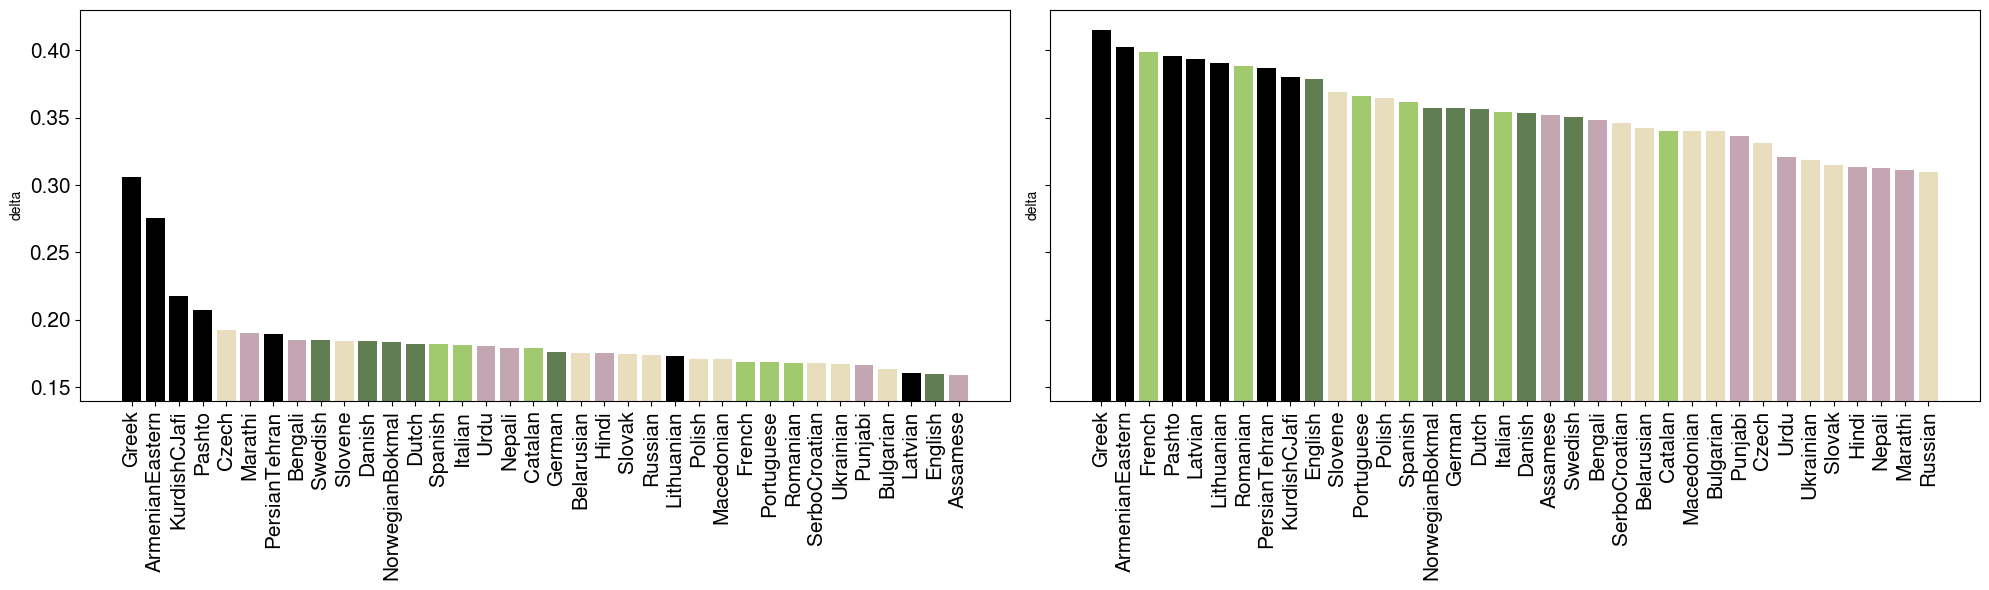

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the specific colors extracted from the screenshot
TARGET_COLORS = {
    "latinofaliscan":   "#a1ca6fff",  # Light Green
    "indoaryan":    "#8b4e6680",  # Maroon/Purple
    "germanic": "#617e52ff",  # Dark Green
    "slavic":   "#d3bd7c80"   # Beige/Gold
}

from matplotlib import font_manager as fm, rcParams

font_path = "nimbus-sans-l/NimbusSanL-Regu.ttf"  # wherever you put it
fm.fontManager.addfont(font_path)
rcParams["font.family"] = "NimbusSanL"       # name inside the font, check with ttfdump if needed

# check if it can be found
print([f.name for f in fm.fontManager.ttflist if "NimbusSanL" in f.name])


def plot_ranked_metric(df, metric, family_map, ax=None, family_colors=None):
    tmp = df.copy()
    tmp["family"] = tmp["name"].map(family_map).fillna("Other")
    tmp = tmp.sort_values(metric, ascending=False).reset_index(drop=True)

    # If no palette provided, build the custom one based on this specific DF
    if family_colors is None:
        family_colors = build_custom_color_map([tmp], family_map)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))

    # Map the colors. If a family somehow isn't in the dict, default to black.
    bar_colors = tmp["family"].map(family_colors).fillna("black")
    
    bars = ax.bar(tmp.index, tmp[metric], color=bar_colors)
    ax.set_xticks(tmp.index)
    ax.set_xticklabels(tmp["name"], rotation=90)
    ax.set_ylabel(metric)
    ax.set_ylim(0.14, 0.43)

    # change fontsize
    ax.tick_params(axis='x', which='major', labelsize=15)
    ax.tick_params(axis='y', which='major', labelsize=15)
    
    # --- LEGEND REMOVED ---
    
    return ax

def build_custom_color_map(dfs, family_map):
    """
    Creates a dictionary where specified families get the screenshot colors,
    and ALL other families get black.
    """
    # 1. Find every unique family across all dataframes
    all_fams = set()
    for _df in dfs:
        # Map names to families, fill NaNs with "Other"
        fams = _df["name"].map(family_map).fillna("Other")
        all_fams.update(fams.unique())

    # 2. Assign colors
    color_map = {}
    for fam in all_fams:
        if fam in TARGET_COLORS:
            color_map[fam] = TARGET_COLORS[fam]
        else:
            color_map[fam] = "black"  # The "All else" rule
            
    return color_map

# --- Main Execution ---

# Load your lookups
family_lookup = {
    'Assamese': 'indoaryan',
    'Afrikaans': 'germanic',
    'Bosnian': 'slavic',
    'Belarusian': 'slavic',
    'Bulgarian': 'slavic',
    'Bengali': 'indoaryan',
    'Catalan': 'latinofaliscan',
    'Czech': 'slavic',
    'Danish': 'germanic',
    'German': 'germanic',
    'Greek': 'Greek',
    'English': 'germanic',
    'Galician': 'latinofaliscan',
    'Gujarati': 'indoaryan',
    'Spanish': 'latinofaliscan',
    'PersianTehran': 'iranian',
    'French': 'latinofaliscan',
    'Hindi': 'indoaryan',
    'Serbian': 'slavic',
    'Croatian': 'slavic',
    'Armenian': 'armenian',
    'Italian': 'latinofaliscan',
    'Lithuanian': 'baltic',
    'Latvian': 'baltic',
    'Macedonian': 'slavic',
    'Marathi': 'indoaryan',
    'NorwegianBokmal': 'germanic',
    'Nepali': 'indoaryan',
    'Oriya': 'indoaryan',
    'Dutch': 'germanic',
    'Punjabi': 'indoaryan',
    'Polish': 'slavic',
    'Pashto': 'iranian',
    'PersianTehran': 'iranian',
    'Portuguese': 'latinofaliscan',
    'Romanian': 'latinofaliscan',
    'Russian': 'slavic',
    # 'Sindhi': 'slavic',
    'Slovak': 'slavic',
    'Slovenian': 'slavic',
    'Slovene': 'slavic',
    'Swedish': 'germanic',
    'Ukrainian': 'slavic',
    'Urdu': 'indoaryan',
    'KurdishCJafiri': 'iranian',
    'SerboCroatian': 'slavic',
}
# Build the map: The 4 specific colors + Black for everything else
shared_family_colors = build_custom_color_map([df_cognates, df_speech], family_lookup)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# make sure df_cognates and df_speech have the same languages
common_languages = set(df_cognates["name"]).intersection(set(df_speech["name"]))
df_cognates = df_cognates[df_cognates["name"].isin(common_languages)].reset_index(drop=True)
df_speech = df_speech[df_speech["name"].isin(common_languages)].reset_index(drop=True)

plot_ranked_metric(df_cognates, "delta", family_lookup, ax=axes[0], family_colors=shared_family_colors)
plot_ranked_metric(df_speech,   "delta", family_lookup, ax=axes[1], family_colors=shared_family_colors)

plt.tight_layout()
plt.savefig("final_figuresv2/delta_ranked_by_family.svg")

## Continuous Maps

In [1]:
# give me code to plot geojson, different color for each "name"
filepath = "dataset.geojson"

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
family_lookup = {
    'Assamese': 'indoaryan',
    'Afrikaans': 'germanic',
    'Bosnian': 'slavic',
    'Belarusian': 'slavic',
    'Bulgarian': 'slavic',
    'Bengali': 'indoaryan',
    'Catalan': 'latinofaliscan',
    'Czech': 'slavic',
    'Danish': 'germanic',
    'German': 'germanic',
    'Greek': 'Greek',
    'English': 'germanic',
    'Galician': 'latinofaliscan',
    'Gujarati': 'indoaryan',
    'Spanish': 'latinofaliscan',
    'PersianTehran': 'iranian',
    'French': 'latinofaliscan',
    'Hindi': 'indoaryan',
    'Serbian': 'slavic',
    'Croatian': 'slavic',
    'Armenian': 'armenian',
    'Italian': 'latinofaliscan',
    'Lithuanian': 'baltic',
    'Latvian': 'baltic',
    'Macedonian': 'slavic',
    'Marathi': 'indoaryan',
    'NorwegianBokmal': 'germanic',
    'Nepali': 'indoaryan',
    'Oriya': 'indoaryan',
    'Dutch': 'germanic',
    'Punjabi': 'indoaryan',
    'Polish': 'slavic',
    'Pashto': 'iranian',
    'PersianTehran': 'iranian',
    'Portuguese': 'latinofaliscan',
    'Romanian': 'latinofaliscan',
    'Russian': 'slavic',
    # 'Sindhi': 'slavic',
    'Slovak': 'slavic',
    'Slovenian': 'slavic',
    'Slovene': 'slavic',
    'Swedish': 'germanic',
    'Ukrainian': 'slavic',
    'Urdu': 'indoaryan',
    'KurdishCJafiri': 'iranian',
    'SerboCroatian': 'slavic',
}
# Load the GeoJSON file
gdf_language = gpd.read_file(filepath)
# rename "name"
renaming = {
    "Slovene": "Slovenian",
    "Punjabi (Panjabi)": "Punjabi",
    "Norwegian" : "NorwegianBokmal",
    # "Galician": # no galician?
    "Persian (Farsi)": "PersianTehran",
    "Belarusian (Belorussian)": "Belarusian",
}
gdf_language["name"] = gdf_language["name"].replace(renaming)
# add same rows to gdf_language with "Serbian / Croatian / Bosnian" but different names with Serbian, Croatian, Bosnian
gdf_extra = gdf_language[gdf_language["name"] == "Serbian / Croatian / Bosnian"]
gdf_serbian = gdf_extra.copy()
gdf_serbian["name"] = "Serbian"
gdf_croatian = gdf_extra.copy()
gdf_croatian["name"] = "Croatian"
gdf_bosnian = gdf_extra.copy()
gdf_bosnian["name"] = "Bosnian"
gdf_language = pd.concat([gdf_language[gdf_language["name"] != "Serbian / Croatian / Bosnian"], gdf_serbian, gdf_croatian, gdf_bosnian], ignore_index=True)
# check if gdf["name"] contains all languages in family_lookup.keys()
missing_langs = set(family_lookup.keys()) - set(gdf_language["name"])
print("Languages in family_lookup but missing in GeoDataFrame:", missing_langs)
# No galician
# gdf_language = gdf_language[gdf_language["name"].isin(family_lookup.keys())].reset_index(drop=True)

Languages in family_lookup but missing in GeoDataFrame: {'Galician', 'SerboCroatian', 'Slovene', 'KurdishCJafiri'}


/home/people/habhuz/miniconda3/envs/speech_phylo/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:
/home/people/habhuz/miniconda3/envs/speech_phylo/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


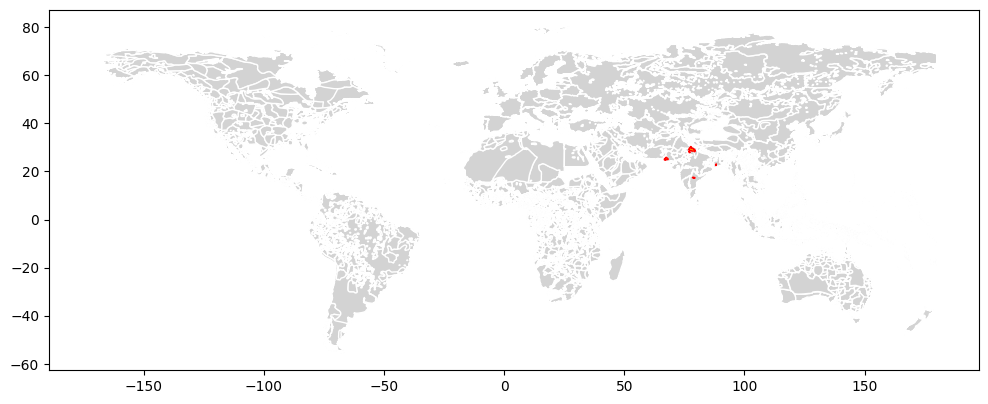

In [2]:
polygons = gdf_language[gdf_language["name"] == "Urdu"].geometry.unary_union
# plot urdu merged
fig, ax = plt.subplots(figsize=(12, 8))
gdf_language.plot(ax=ax, color="lightgray", edgecolor="white")
gpd.GeoSeries([polygons]).plot(ax=ax, color="orange", edgecolor="red")
plt.show()

In [ ]:
# gp_country_choropleth_eu_india_continuous_posterior_product.py
import os, sys
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.prepared import prep
from sklearn.preprocessing import StandardScaler
import gpflow, tensorflow as tf
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------- config ----------------
tree_names = ["heggarty2024", "long_v3_CCD0.0.25"]
tree_name_mapping = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech"
}
meta_dir = "final_phyloregression_results"
out_dir = "final_figuresv2"
os.makedirs(out_dir, exist_ok=True)

CMAP = "viridis"
GRID_N_LON = 400
GRID_N_LAT = 300
FIXED_NOISE = 1e-4
PAD_DEG = 15

# ---------------- exclusions ----------------
EXCLUDE_LANGUAGES = {
    "Turkish", "Finnish", "Hungarian", "Icelandic",
    "Irish", "Welsh", "Breton", "Cornish",
    "Scottish Gaelic", "Gaelic", "Manx",
}

family_lookup = {
    'Assamese': 'indoaryan',
    'Afrikaans': 'germanic',
    'Bosnian': 'slavic',
    'Belarusian': 'slavic',
    'Bulgarian': 'slavic',
    'Bengali': 'indoaryan',
    'Catalan': 'latinofaliscan',
    'Czech': 'slavic',
    'Danish': 'germanic',
    'German': 'germanic',
    'Greek': 'Greek',
    'English': 'germanic',
    'Galician': 'latinofaliscan',
    'Gujarati': 'indoaryan',
    'Spanish': 'latinofaliscan',
    'PersianTehran': 'iranian',
    'French': 'latinofaliscan',
    'Hindi': 'indoaryan',
    'Serbian': 'slavic',
    'Croatian': 'slavic',
    'Armenian': 'armenian',
    'Italian': 'latinofaliscan',
    'Lithuanian': 'baltic',
    'Latvian': 'baltic',
    'Macedonian': 'slavic',
    'Marathi': 'indoaryan',
    'NorwegianBokmal': 'germanic',
    'Nepali': 'indoaryan',
    'Oriya': 'indoaryan',
    'Dutch': 'germanic',
    'Punjabi': 'indoaryan',
    'Polish': 'slavic',
    'Pashto': 'iranian',
    'PersianTehran': 'iranian',
    'Portuguese': 'latinofaliscan',
    'Romanian': 'latinofaliscan',
    'Russian': 'slavic',
    # 'Sindhi': 'slavic',
    'Slovak': 'slavic',
    'Slovenian': 'slavic',
    'Slovene': 'slavic',
    'Swedish': 'germanic',
    'Ukrainian': 'slavic',
    'Urdu': 'indoaryan',
    'KurdishCJafiri': 'iranian',
    'SerboCroatian': 'slavic',
}

family_markers = {
    'germanic': 's',
    'slavic': '^',
    'baltic': 'D',
    'indoaryan': 'o',
    'latinofaliscan': 'v',
    'iranian': 'P',
    'armenian': 'X',
    'Greek': 'h',
    'other': 'o',
}


# ---------------- Load language polygons ----------------
def load_language_polygons(filepath):
    """Load and preprocess language GeoJSON."""
    gdf = gpd.read_file(filepath)

    # for all name, merge polygons into one
    for name in gdf["name"].unique():
        polygons = gdf[gdf["name"] == name].geometry.unary_union
        gdf = gdf[gdf["name"] != name]
        gdf = gdf.append({"name": name, "geometry": polygons}, ignore_index=True)
    
    renaming = {
        "Punjabi (Panjabi)": "Punjabi",
        "Norwegian": "NorwegianBokmal",
        "Persian (Farsi)": "PersianTehran",
        "Belarusian (Belorussian)": "Belarusian",
        "Kurdish": "KurdishCJafiri",
        "Netherlandic": "Dutch"
    }
    gdf["name"] = gdf["name"].replace(renaming)
    
    # Split Serbian / Croatian / Bosnian into separate rows
    # scb_mask = gdf["name"] == "Serbian / Croatian / Bosnian"
    # gdf_scb = gdf[scb_mask]
    # gdf_rest = gdf[~scb_mask]
    
    # expanded = []
    # for lang in ["Serbian", "Croatian", "Bosnian"]:
    #     g = gdf_scb.copy()
    #     g["name"] = lang
    #     expanded.append(g)

    # replace "Serbian / Croatian / Bosnian" with "SerboCroatian"
    scb_mask = gdf["name"] == "Serbian / Croatian / Bosnian"
    gdf_scb = gdf[scb_mask]
    gdf_rest = gdf[~scb_mask]
    gdf_scb["name"] = "SerboCroatian"
    
    # gdf = pd.concat([gdf_rest] + expanded, ignore_index=True)
    gdf = pd.concat([gdf_rest, gdf_scb], ignore_index=True)
    gdf = gdf[gdf["name"].isin(family_lookup.keys())].reset_index(drop=True)
    
    return gdf


# ---------------- geography ----------------
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# ROI bounds
ire = world.loc[world['name'] == 'Ireland'].total_bounds
bgd = world.loc[world['name'] == 'Bangladesh'].total_bounds
ROI_MINX = min(ire[0], bgd[0]) - PAD_DEG
ROI_MAXX = max(ire[2], bgd[2]) + PAD_DEG
ROI_MINY = min(ire[1], bgd[1]) - PAD_DEG
ROI_MAXY = max(ire[3], bgd[3]) + PAD_DEG
ROI_BOX = box(ROI_MINX, ROI_MINY, ROI_MAXX, ROI_MAXY)

land_union = world.unary_union
land_gdf = gpd.GeoDataFrame(geometry=[land_union], crs=world.crs)


# ---------------- utilities ----------------
def tidy_meta(meta: pd.DataFrame) -> pd.DataFrame:
    meta = meta.rename(columns={"level_0": "language_true"})
    for col in list(meta.columns):
        if meta[col].dtype == object and meta[col].astype(str).str.contains(",", na=False).any():
            new_cols = meta[col].astype(str).str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            meta.drop(columns=[col], inplace=True)
    meta.drop(columns=meta.columns[1:7], errors='ignore', inplace=True)
    meta.rename(columns={"language_true": "language"}, inplace=True)
    meta["language"] = meta["language"].astype(str).str.strip()
    return meta.set_index("language")


def fit_gp_from_points(X, y):
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    kernel = gpflow.kernels.Matern32(lengthscales=1.0, variance=1.0)
    model = gpflow.models.GPR(
        data=(X_scaled, y_scaled.reshape(-1, 1)),
        kernel=kernel,
        mean_function=None
    )

    model.likelihood.variance.assign(FIXED_NOISE)
    gpflow.set_trainable(model.likelihood.variance, False)

    gpflow.optimizers.Scipy().minimize(
        model.training_loss,
        variables=model.trainable_variables,
        options=dict(maxiter=500)
    )
    return model, scaler_X, scaler_y


# ---------------- main ----------------
geojson_path = "dataset.geojson"
gdf_language = load_language_polygons(geojson_path)

for tree_name in tree_names:
    meta_path = f"{meta_dir}/metadata_{tree_name}.csv"
    if not os.path.exists(meta_path):
        print(f"[warn] {meta_path} not found; skipping.")
        continue

    meta = pd.read_csv(meta_path, sep=",")
    meta = tidy_meta(meta)
    meta = meta.loc[~meta.index.isin(EXCLUDE_LANGUAGES)].copy()

    if meta.empty:
        print(f"[{tree_name}] All rows excluded; skipping.")
        continue

    meta["family"] = meta.index.map(lambda x: family_lookup.get(x, "other"))

    # Fit GP
    X_all = meta[['longitude', 'latitude']].to_numpy()
    y_all = meta['rate_median'].to_numpy()

    model, scaler_X, scaler_y = fit_gp_from_points(X_all, y_all)

    # Posterior at observation locations
    X_obs_scaled = scaler_X.transform(X_all)
    m_obs, v_obs = model.predict_f(X_obs_scaled)
    mean_obs = m_obs.numpy().ravel()
    std_obs = np.sqrt(v_obs.numpy().ravel())

    meta["rate_mean"] = mean_obs
    meta["rate_std"] = std_obs
    meta["rate_eff"] = mean_obs * (1.0 - std_obs)

    # --- Create union of all language polygons ---
    gdf_clipped = gpd.clip(gdf_language, ROI_BOX)
    # Only keep languages that are in our metadata
    gdf_clipped = gdf_clipped[gdf_clipped["name"].isin(meta.index)].copy()
    language_union = gdf_clipped.unary_union
    language_union_prep = prep(language_union)

    # --- Grid for continuous interpolation ---
    lon_grid = np.linspace(ROI_MINX, ROI_MAXX, GRID_N_LON)
    lat_grid = np.linspace(ROI_MINY, ROI_MAXY, GRID_N_LAT)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    grid_points = np.column_stack([LON.ravel(), LAT.ravel()])

    # Mask: only points inside language polygons
    in_language_mask = np.array(
        [language_union_prep.contains(Point(p[0], p[1])) for p in grid_points]
    ).reshape(LON.shape)

    # GP prediction on grid
    Xg = scaler_X.transform(grid_points)
    mean_grid, var_grid = model.predict_f(Xg)

    mean_np = mean_grid.numpy().ravel().reshape(LON.shape)
    std_np = np.sqrt(var_grid.numpy().ravel()).reshape(LON.shape)

    # Effective value = mean * (1 - std)
    Z_eff = np.full(LON.shape, np.nan, dtype=float)
    Z_eff[in_language_mask] = mean_np[in_language_mask] * (1.0 - std_np[in_language_mask])

    # Color normalization
    vals = []
    if np.isfinite(Z_eff).any():
        vals.append(Z_eff[np.isfinite(Z_eff)].ravel())
    vals.append(meta['rate_eff'].to_numpy())
    vals = np.concatenate([v[np.isfinite(v)] for v in vals])
    
    if vals.size > 0:
        vmin, vmax = np.quantile(vals, 0.02), np.quantile(vals, 0.98)
    else:
        vmin, vmax = 0, 1

    cmap = plt.get_cmap(CMAP)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # ------- Plot -------
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))

    # Basemap
    land_roi = gpd.clip(land_gdf, ROI_BOX)
    ax.set_facecolor("#d5e9ff")
    land_roi.plot(ax=ax, color='white', edgecolor='none', zorder=0)
    land_roi.boundary.plot(ax=ax, color='lightgray', linewidth=0.6, zorder=0.5)

    # Continuous raster within language polygons
    if np.isfinite(Z_eff).any():
        ax.pcolormesh(
            LON, LAT, Z_eff, shading="auto",
            cmap=cmap, norm=norm,
            zorder=1
        )

    # Language polygon boundaries (outlines only)
    gdf_clipped.boundary.plot(ax=ax, color='white', linewidth=0.8, zorder=2)

    # Observation points with family-specific markers
    for fam, sub in meta.groupby("family"):
        marker = family_markers.get(fam, 'o')
        ax.scatter(
            sub["longitude"],
            sub["latitude"],
            s=60,
            c=sub["rate_eff"],
            cmap=cmap,
            norm=norm,
            marker=marker,
            edgecolor='black',
            linewidth=0.7,
            alpha=1.0,
            zorder=10,
        )

    # Family legend
    families_present = [f for f in sorted(meta["family"].unique()) if f not in ("other", "")]
    legend_handles = []
    for fam in families_present:
        marker = family_markers.get(fam, 'o')
        h = ax.scatter([], [], marker=marker, color='black', s=40, label=fam.capitalize())
        legend_handles.append(h)
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper left', fontsize=12, framealpha=0.9, title="Family")

    # Labels for high-rate languages
    threshold = np.percentile(meta["rate_eff"], 90)
    for lang, row in meta.iterrows():
        if row["rate_eff"] > threshold:
            ax.annotate(
                lang,
                (row["longitude"], row["latitude"]),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='black', alpha=0.8, linewidth=0.5),
                zorder=11,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                                color='black', lw=0.5, alpha=0.6)
            )

    ax.set_xlim(ROI_MINX, ROI_MAXX)
    ax.set_ylim(ROI_MINY, ROI_MAXY)
    ax.set_xlabel("Longitude", fontsize=18)
    ax.set_ylabel("Latitude", fontsize=18)
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)


    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label("Posterior mean × (1 − posterior SD)", fontsize=18, fontweight="bold")
    # set colorbar lims
    sm.set_clim(-0.4, 0.5)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"language_polygons_continuous_{tree_name}.svg")
    # save SVG only
    fig.savefig(fig_path, dpi=300)
    print(f"[{tree_name}] wrote figure: {fig_path}")

In [ ]:
# gp_country_choropleth_eu_india_continuous_posterior_product.py
import os, sys
sys.path.append("../")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.strtree import STRtree
from sklearn.preprocessing import StandardScaler
import gpflow, tensorflow as tf
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------- config ----------------
tree_names = ["heggarty2024", "long_v3_CCD0.0.25"]
tree_name_mapping = {
    "heggarty2024": "Cognates",
    "long_v3_CCD0.0.25": "Speech"
}
meta_dir = "final_phyloregression_results"
out_dir = "final_figuresv2"
os.makedirs(out_dir, exist_ok=True)

CMAP = "viridis"
GRID_N_LON_TRAIN = 150   # coarser grid for training (memory)
GRID_N_LAT_TRAIN = 100
GRID_N_LON_PRED = 400    # finer grid for prediction/plotting
GRID_N_LAT_PRED = 300
FIXED_NOISE = 1e-2       # slightly higher noise since we have pseudo-replicates
PAD_DEG = 15

# ---------------- exclusions ----------------
EXCLUDE_LANGUAGES = {
    "Turkish", "Finnish", "Hungarian", "Icelandic",
    "Irish", "Welsh", "Breton", "Cornish",
    "Scottish Gaelic", "Gaelic", "Manx",
}
family_lookup = {
    'Assamese': 'indoaryan',
    'Afrikaans': 'germanic',
    'Bosnian': 'slavic',
    'Belarusian': 'slavic',
    'Bulgarian': 'slavic',
    'Bengali': 'indoaryan',
    'Catalan': 'latinofaliscan',
    'Czech': 'slavic',
    'Danish': 'germanic',
    'German': 'germanic',
    'Greek': 'Greek',
    'English': 'germanic',
    'Galician': 'latinofaliscan',
    'Gujarati': 'indoaryan',
    'Spanish': 'latinofaliscan',
    'PersianTehran': 'iranian',
    'French': 'latinofaliscan',
    'Hindi': 'indoaryan',
    'Serbian': 'slavic',
    'Croatian': 'slavic',
    'Armenian': 'armenian',
    'Italian': 'latinofaliscan',
    'Lithuanian': 'baltic',
    'Latvian': 'baltic',
    'Macedonian': 'slavic',
    'Marathi': 'indoaryan',
    'NorwegianBokmal': 'germanic',
    'Nepali': 'indoaryan',
    'Oriya': 'indoaryan',
    'Dutch': 'germanic',
    'Punjabi': 'indoaryan',
    'Polish': 'slavic',
    'Pashto': 'iranian',
    'PersianTehran': 'iranian',
    'Portuguese': 'latinofaliscan',
    'Romanian': 'latinofaliscan',
    'Russian': 'slavic',
    # 'Sindhi': 'slavic',
    'Slovak': 'slavic',
    'Slovenian': 'slavic',
    'Slovene': 'slavic',
    'Swedish': 'germanic',
    'Ukrainian': 'slavic',
    'Urdu': 'indoaryan',
    'KurdishCJafiri': 'iranian',
    'SerboCroatian': 'slavic',
}

family_markers = {
    'germanic': 's',
    'slavic': '^',
    'baltic': 'D',
    'indoaryan': 'o',
    'latinofaliscan': 'v',
    'iranian': 'P',
    'armenian': 'X',
    'Greek': 'h',
    'other': 'o',
}


# ---------------- Load language polygons ----------------
def load_language_polygons(filepath):
    """Load and preprocess language GeoJSON."""
    gdf = gpd.read_file(filepath)
    # there are three rows with "Serbian / Croatian / Bosnian"
    # merge them into one
    # for all name, merge polygons into one
    for name in gdf["name"].unique():
        polygons = gdf[gdf["name"] == name].geometry.unary_union
        gdf = gdf[gdf["name"] != name]
        gdf = gdf.append({"name": name, "geometry": polygons}, ignore_index=True)
    
    renaming = {
        "Slovene": "Slovenian",
        "Punjabi (Panjabi)": "Punjabi",
        "Norwegian": "NorwegianBokmal",
        "Persian (Farsi)": "PersianTehran",
        "Belarusian (Belorussian)": "Belarusian",
        "Kurdish": "KurdishCJafiri",
        "Netherlandic": "Dutch"
    }
    gdf["name"] = gdf["name"].replace(renaming)
    
    scb_mask = gdf["name"] == "Serbian / Croatian / Bosnian"
    gdf_scb = gdf[scb_mask]
    gdf_rest = gdf[~scb_mask]
    
    expanded = []
    for lang in ["Serbian", "Croatian", "Bosnian"]:
        g = gdf_scb.copy()
        g["name"] = lang
        expanded.append(g)
    
    gdf = pd.concat([gdf_rest] + expanded, ignore_index=True)
    gdf = gdf[gdf["name"].isin(family_lookup.keys())].reset_index(drop=True)
    
    return gdf


# ---------------- geography ----------------
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

ire = world.loc[world['name'] == 'Ireland'].total_bounds
bgd = world.loc[world['name'] == 'Bangladesh'].total_bounds
ROI_MINX = min(ire[0], bgd[0]) - PAD_DEG
ROI_MAXX = max(ire[2], bgd[2]) + PAD_DEG
ROI_MINY = min(ire[1], bgd[1]) - PAD_DEG
ROI_MAXY = max(ire[3], bgd[3]) + PAD_DEG
ROI_BOX = box(ROI_MINX, ROI_MINY, ROI_MAXX, ROI_MAXY)

land_union = world.unary_union
land_gdf = gpd.GeoDataFrame(geometry=[land_union], crs=world.crs)


# ---------------- utilities ----------------
def tidy_meta(meta: pd.DataFrame) -> pd.DataFrame:
    meta = meta.rename(columns={"level_0": "language_true"})
    for col in list(meta.columns):
        if meta[col].dtype == object and meta[col].astype(str).str.contains(",", na=False).any():
            new_cols = meta[col].astype(str).str.split(",", expand=True)
            meta[f"{col}_lo"] = pd.to_numeric(new_cols[0], errors='coerce')
            meta[f"{col}_hi"] = pd.to_numeric(new_cols[1], errors='coerce')
            meta.drop(columns=[col], inplace=True)
    meta.drop(columns=meta.columns[1:7], errors='ignore', inplace=True)
    meta.rename(columns={"language_true": "language"}, inplace=True)
    meta["language"] = meta["language"].astype(str).str.strip()
    return meta.set_index("language")


def create_polygon_grid_training_data(gdf_language, meta, roi_box, n_lon, n_lat):
    """
    Create training data by assigning each grid point inside a language polygon
    the rate value of that language.
    
    Returns X (lon, lat), y (rate values), and language labels.
    """
    # Clip polygons to ROI
    gdf_clipped = gpd.clip(gdf_language, roi_box)
    gdf_clipped = gdf_clipped[gdf_clipped["name"].isin(meta.index)].copy()
    
    # Add rate values to polygons
    gdf_clipped["rate"] = gdf_clipped["name"].map(meta["rate_median"])
    gdf_clipped = gdf_clipped.dropna(subset=["rate"]).reset_index(drop=True)
    
    # Create grid
    lon_grid = np.linspace(roi_box.bounds[0], roi_box.bounds[2], n_lon)
    lat_grid = np.linspace(roi_box.bounds[1], roi_box.bounds[3], n_lat)
    LON, LAT = np.meshgrid(lon_grid, lat_grid)
    grid_points = np.column_stack([LON.ravel(), LAT.ravel()])
    
    # Build spatial index for fast lookup
    geometries = gdf_clipped.geometry.values
    tree = STRtree(geometries)
    
    # Assign each grid point to a language polygon
    X_train = []
    y_train = []
    lang_labels = []
    
    for lon, lat in grid_points:
        pt = Point(lon, lat)
        # Query returns indices in newer shapely
        candidate_indices = tree.query(pt)
        for idx in candidate_indices:
            geom = geometries[idx]
            if geom.contains(pt):
                rate = gdf_clipped.iloc[idx]["rate"]
                lang = gdf_clipped.iloc[idx]["name"]
                X_train.append([lon, lat])
                y_train.append(rate)
                lang_labels.append(lang)
                break  # take first match
    
    return np.array(X_train), np.array(y_train), lang_labels, gdf_clipped

def predict_in_batches(model, scaler_X, grid_points, batch_size=5000):
    """Predict GP in batches to avoid memory issues."""
    n_points = len(grid_points)
    mean_all = []
    var_all = []
    
    for i in range(0, n_points, batch_size):
        batch = grid_points[i:i+batch_size]
        Xg = scaler_X.transform(batch)
        mean_batch, var_batch = model.predict_f(Xg)
        mean_all.append(mean_batch.numpy().ravel())
        var_all.append(var_batch.numpy().ravel())
    
    return np.concatenate(mean_all), np.concatenate(var_all)

def fit_gp_from_points(X, y, noise_variance=FIXED_NOISE):
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    kernel = gpflow.kernels.Matern32(lengthscales=1.0, variance=1.0)
    model = gpflow.models.GPR(
        data=(X_scaled, y_scaled.reshape(-1, 1)),
        kernel=kernel,
        mean_function=None
    )

    model.likelihood.variance.assign(noise_variance)
    gpflow.set_trainable(model.likelihood.variance, False)

    gpflow.optimizers.Scipy().minimize(
        model.training_loss,
        variables=model.trainable_variables,
        options=dict(maxiter=500)
    )
    print(f"  Trained on {X.shape[0]} pseudo-observations")
    print(f"  Optimized kernel: {model.kernel}")
    return model, scaler_X, scaler_y


# ---------------- main ----------------
geojson_path = "dataset.geojson"
gdf_language = load_language_polygons(geojson_path)

for tree_name in tree_names:
    print(f"\n[{tree_name}] Processing...")
    
    meta_path = f"{meta_dir}/metadata_{tree_name}.csv"
    if not os.path.exists(meta_path):
        print(f"  [warn] {meta_path} not found; skipping.")
        continue

    meta = pd.read_csv(meta_path, sep=",")
    meta = tidy_meta(meta)
    meta = meta.loc[~meta.index.isin(EXCLUDE_LANGUAGES)].copy()

    if meta.empty:
        print(f"  All rows excluded; skipping.")
        continue

    meta["family"] = meta.index.map(lambda x: family_lookup.get(x, "other"))

    # --- Create training data from polygon grid ---
    print("  Creating polygon-based training grid...")
    X_train, y_train, lang_labels, gdf_clipped = create_polygon_grid_training_data(
        gdf_language, meta, ROI_BOX, GRID_N_LON_TRAIN, GRID_N_LAT_TRAIN
    )
    
    if len(X_train) == 0:
        print("  No training points generated; skipping.")
        continue

    # --- Fit GP on polygon grid ---
    print(f"  Fitting GP with {X_train.shape[0]} training points...")
    model, scaler_X, scaler_y = fit_gp_from_points(X_train, y_train, noise_variance=FIXED_NOISE)

    # --- Prediction grid (finer) ---
    # --- Prediction grid (finer) ---
    lon_pred = np.linspace(ROI_MINX, ROI_MAXX, GRID_N_LON_PRED)
    lat_pred = np.linspace(ROI_MINY, ROI_MAXY, GRID_N_LAT_PRED)
    LON, LAT = np.meshgrid(lon_pred, lat_pred)
    grid_pred = np.column_stack([LON.ravel(), LAT.ravel()])

    # Mask: only predict inside language polygons
    language_union = gdf_clipped.unary_union
    from shapely.prepared import prep
    language_union_prep = prep(language_union)
    
    print("  Creating prediction mask...")
    in_language_mask = np.array(
        [language_union_prep.contains(Point(p[0], p[1])) for p in grid_pred]
    )
    
    # Only predict for points inside polygons (saves memory)
    grid_pred_inside = grid_pred[in_language_mask]
    
    print(f"  Predicting on {len(grid_pred_inside)} points (inside polygons)...")
    mean_inside, var_inside = predict_in_batches(model, scaler_X, grid_pred_inside, batch_size=5000)
    std_inside = np.sqrt(var_inside)
    eff_inside = mean_inside * (1.0 - std_inside)
    
    # Reconstruct full grid
    Z_eff = np.full(len(grid_pred), np.nan, dtype=float)
    Z_eff[in_language_mask] = eff_inside
    Z_eff = Z_eff.reshape(LON.shape)
    in_language_mask = in_language_mask.reshape(LON.shape)

    # GP prediction
    print("  Predicting on fine grid...")
    Xg = scaler_X.transform(grid_pred)
    mean_grid, var_grid = model.predict_f(Xg)

    mean_np = mean_grid.numpy().ravel().reshape(LON.shape)
    std_np = np.sqrt(var_grid.numpy().ravel()).reshape(LON.shape)

    # Effective value within polygons only
    Z_eff = np.full(LON.shape, np.nan, dtype=float)
    Z_eff[in_language_mask] = mean_np[in_language_mask] * (1.0 - std_np[in_language_mask])

    # Also compute rate_eff at original observation points for scatter coloring
    X_obs = meta[['longitude', 'latitude']].to_numpy()
    X_obs_scaled = scaler_X.transform(X_obs)
    m_obs, v_obs = model.predict_f(X_obs_scaled)
    meta["rate_mean"] = m_obs.numpy().ravel()
    meta["rate_std"] = np.sqrt(v_obs.numpy().ravel())
    meta["rate_eff"] = meta["rate_mean"] * (1.0 - meta["rate_std"])

    # Color normalization
    vals = []
    if np.isfinite(Z_eff).any():
        vals.append(Z_eff[np.isfinite(Z_eff)].ravel())
    vals.append(meta['rate_eff'].to_numpy())
    vals = np.concatenate([v[np.isfinite(v)] for v in vals])
    
    vmin, vmax = np.quantile(vals, 0.02), np.quantile(vals, 0.98) if vals.size > 0 else (0, 1)

    cmap = plt.get_cmap(CMAP)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # ------- Plot -------
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))

    # Basemap
    land_roi = gpd.clip(land_gdf, ROI_BOX)
    ax.set_facecolor("#d5e9ff")
    land_roi.plot(ax=ax, color='white', edgecolor='none', zorder=0)
    land_roi.boundary.plot(ax=ax, color='lightgray', linewidth=0.6, zorder=0.5)

    # Continuous raster
    if np.isfinite(Z_eff).any():
        ax.pcolormesh(
            LON, LAT, Z_eff, shading="auto",
            cmap=cmap, norm=norm,
            zorder=1
        )

    # Language polygon boundaries
    gdf_clipped.boundary.plot(ax=ax, color='white', linewidth=0.8, zorder=2)

    # Observation points
    for fam, sub in meta.groupby("family"):
        marker = family_markers.get(fam, 'o')
        ax.scatter(
            sub["longitude"],
            sub["latitude"],
            s=60,
            c=sub["rate_eff"],
            cmap=cmap,
            norm=norm,
            marker=marker,
            edgecolor='black',
            linewidth=0.7,
            alpha=1.0,
            zorder=10,
        )

    # Family legend
    families_present = [f for f in sorted(meta["family"].unique()) if f not in ("other", "")]
    legend_handles = [
        ax.scatter([], [], marker=family_markers.get(f, 'o'), color='black', s=40, label=f.capitalize())
        for f in families_present
    ]
    if legend_handles:
        ax.legend(handles=legend_handles, loc='upper left', fontsize=12, framealpha=0.9, title="Family")

    # Labels for high-rate languages
    threshold = np.percentile(meta["rate_eff"], 90)
    for lang, row in meta.iterrows():
        if row["rate_eff"] > threshold:
            ax.annotate(
                lang,
                (row["longitude"], row["latitude"]),
                xytext=(8, 8),
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='black', alpha=0.8, linewidth=0.5),
                zorder=11,
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                                color='black', lw=0.5, alpha=0.6)
            )

    ax.set_xlim(ROI_MINX, ROI_MAXX)
    ax.set_ylim(ROI_MINY, ROI_MAXY)
    ax.set_xlabel("Longitude", fontsize=18)
    ax.set_ylabel("Latitude", fontsize=18)
    ax.tick_params(axis="both", labelsize=18)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.6)

    # Colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label("Posterior mean × (1 − posterior SD)", fontsize=18, fontweight="bold")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"language_polygons_gridtrain_{tree_name}.svg")
    fig.savefig(fig_path, dpi=300)
    print(f"  Wrote figure: {fig_path}")


[heggarty2024] Processing...
  Creating polygon-based training grid...
